# Factores de los videojuegos que ayudarán a determinar su éxito.

Ice, una tienda online global de videojuegos, busca entender los factores que determinan el éxito o fracaso de un videojuego. Para ello, utiliza datos de código abierto que incluyen reseñas de usuarios y profesionales, géneros, plataformas y ventas históricas.

El proceso inicia con la preparación de los datos: se corrigen inconsistencias, valores faltantes y tipos de datos erróneos. Luego, se calculan las ventas globales sumando las ventas de cada región (América del Norte, Europa, Japón y otras).

Una vez listos, los datos se analizan para identificar patrones que ayuden a predecir el éxito de un videojuego. Finalmente, se exploran dos aspectos clave: la clasificación de usuarios por plataforma y género. También se comparan las calificaciones de usuarios de Xbox 1 y PC, y se evalúa la variación en las calificaciones promedio para los géneros de acción y estilo. Estos hallazgos culminarán en un informe con las conclusiones generales.

## Inicialización

In [ ]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

## Cargar datos

In [2]:
# Cargar el archivo de datos games.csv
games = pd.read_csv('/datasets/games.csv')

## Explorando los datos

In [3]:
# Imprimir la información general/resumida sobre el DataFrame de las tarifas
#games.describe()
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Hay `16.715` filas en el conjunto de datos. Sin embargo, se puede observar que algunas columnas contienen valores nulos (faltantes), ya que sus valores no nulos reportados son menores que `16.715`. Faltan datos en las siguientes columnas:

- `'Name'`
- `'Year_of_Release'`
- `'Genre'`
- `'Critic_Score'`
- `'User_Score'`
- `'Rating'`
  
Uno de los problemas más notables es que a las columnas `'User_Score'` y `'Rating'` les falta casi un tercio de sus valores. Será necesario investigar esto más a fondo para determinar si se pueden completar los valores faltantes o si se deben eliminar las columnas.

Al analizar los tipos de datos, la columna `'Year_of_Release'` debe contener enteros y la columna `'User_Score'` debe contener valores float64. Sin embargo, la columna `'Year_of_Release'` contiene valores del tipo float64, y la columna `'User_score'` contiene valores del tipo object. Estos dos tipos de datos deberán convertirse a tipos de datos más adecuados.

In [4]:
# Imprimir una muestra de los datos
#games.sample(n = 20)
games.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


## Corregir datos

El primer paso en la limpieza de datos es convertir los nombres de las columnas a minúsculas. Esto facilita su uso al evitar la necesidad de escribir mayúsculas al llamarlas, lo que optimiza el tiempo y reduce posibles errores en el proceso.

In [5]:
# Reemplazar los nombres de las columnas (ponerlos en minúsculas)
games.columns = games.columns.str.lower()

# Mostrar los nombres de las columnas
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

Es hora de empezar a revisar los datos faltantes de cada columna y solucionarlos. La primera columna con la que comenzaremos es la del nombre.

In [6]:
# Imprimir los valores faltantes en la columna 'name'
games[games['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Dado que únicamente hay dos valores faltantes en la columna de nombres dentro del conjunto de datos, podemos eliminar esas filas sin riesgo de afectar los resultados finales.

In [7]:
# Eliminar las filas de 'name' con valores ausentes
games = games.dropna(subset = ['name'])

In [8]:
# Verificar si se realizó el correcto procedimiento
games['name'].isnull().sum()

0

La siguiente columna será `'year_of_release'`.

In [9]:
# Imprimir los valores faltantes en la columna 'year_of_release'
games[games['year_of_release'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Tenemos 269 valores faltantes en la columna `'year_of_release'`, lo que representa el 1.61 % del conjunto de datos. Podemos eliminar esas filas sin que afecte significativamente el análisis.

In [10]:
# Eliminar las filas de 'year_of_release' con valores ausentes
games = games.dropna(subset = ['year_of_release'])

In [11]:
# Verificar si se realizó el correcto procedimiento
games['year_of_release'].isnull().sum()

0

Ahora, analicemos el tipo de dato de la columna `'year_of_release'` que actualmente es float64. Dado que los valores representan años, convertiremos todos los valores de la columna `'year_of_release'` a enteros.

In [12]:
# Verificar el tipo actual
games['year_of_release'].dtype

dtype('float64')

In [13]:
# Convertir a entero
games['year_of_release'] = games['year_of_release'].astype('int')

In [14]:
# Verificar que se convirtió correctamente
games['year_of_release'].dtype

dtype('int64')

Ahora veamos la columna `'genre'`.

In [15]:
# Imprimir los valores faltantes en la columna 'genre'
games[games['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


Parece que, tras eliminar las filas con valores faltantes en las columnas `'name'` o `'year_of_release'`, ya no quedan filas con valores faltantes en la columna `'genre'`. No se requiere ninguna acción adicional.

La siguiente es la columna `'critic_score'`.

In [16]:
# Imprimir los valores faltantes en la columna 'critic_score'
games[games['critic_score'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [17]:
# Imprimir el número de valores faltantes en la columna 'critic_score'
games['critic_score'].isnull().sum()

8461

La columna `'critic_score'` presenta aproximadamente un 50 % de valores nulos. Debido a la alta proporción de datos faltantes y la falta de un criterio confiable para imputarlos, se ha decidido conservar los valores como NaN. Esto nos permitirá continuar con el análisis sin introducir sesgos, y en caso de ser necesario, se evaluarán métodos de imputación más adelante.

La siguiente es la columna `'user_score'`.

In [18]:
# Imprimir los valores faltantes en la columna 'user_score'
games[games['user_score'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


La columna `'user_score'` contiene aproximadamente un 39 % de datos faltantes. Además, ciertos valores están marcados como 'tbd' (To Be Determined), los cuales no representan puntuaciones válidas y fueron tratados como valores nulos. Al no contar con información suficiente para una imputación precisa, se optó por conservar estos valores como NaN.

In [19]:
# Comprobar si hay valores 'tbd' en la columna 'user_score'
games[games['user_score'] == 'tbd']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.0,0.66,NaN,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005,Misc,2.08,1.35,0.0,0.54,61.0,tbd,E10+
520,Zumba Fitness 2,Wii,2011,Sports,1.51,1.03,0.0,0.27,NaN,tbd,T
645,uDraw Studio,Wii,2010,Misc,1.65,0.57,0.0,0.20,71.0,tbd,E
718,Just Dance Kids,Wii,2010,Misc,1.52,0.54,0.0,0.18,NaN,tbd,E
...,...,...,...,...,...,...,...,...,...,...,...
16695,Planet Monsters,GBA,2001,Action,0.01,0.00,0.0,0.00,67.0,tbd,E
16697,Bust-A-Move 3000,GC,2003,Puzzle,0.01,0.00,0.0,0.00,53.0,tbd,E
16698,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.0,0.00,48.0,tbd,E
16704,Plushees,DS,2008,Simulation,0.01,0.00,0.0,0.00,NaN,tbd,E


In [20]:
# Reemplazar valores 'tbd' con NaN
games['user_score'] = games['user_score'].replace('tbd', np.nan)

Ahora cambiamos el tipo de dato object a float64

In [21]:
# Verificar el tipo de dato actual
games['user_score'].dtype

dtype('O')

In [22]:
# Convertir a flot
games['user_score'] = games['user_score'].astype('float')

In [23]:
# Verificar que se convirtió correctamente
games['user_score'].dtype

dtype('float64')

In [24]:
# Verifique los valores faltantes en la columna 'user_score'
games[games['user_score'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [25]:
# Verificar el número de valores faltantes en la columna 'user_score'
games['user_score'].isnull().sum()

8981

La siguiente columna es `'rating'`.

In [26]:
# Imprimir los valores faltantes en la columna 'rating'
games[games['rating'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [27]:
# Completar los valores faltantes en la columna de 'rating' con 'unknown'
games['rating'] = games['rating'].fillna('unknown')

In [28]:
# Contar los valores de 'rating'
games['rating'].value_counts()

unknown    6676
E          3921
T          2905
M          1536
E10+       1393
EC            8
K-A           3
RP            1
AO            1
Name: rating, dtype: int64

 Al observar los valores de las calificaciones, vemos que algunas tienen menos de 10 valores. Tras investigar, deduzco que algunas calificaciones provienen de diferentes sistemas de calificación a nivel mundial. Combinaremos estos valores con las contrapartes populares.

Al analizar la columna `'rating'`, se observaron algunas categorías con muy pocos registros, como `'EC'`, `'K-A'`, `'AO'` y `'RP'`. Estas calificaciones provienen de diferentes sistemas de clasificación y, en algunos casos, corresponden a versiones antiguas o poco utilizadas. Para simplificar el análisis y evitar la dispersión de valores, se decidió agrupar estas categorías en sus equivalentes más representativas. Específicamente, se reemplazó `'EC'` por `'E'` (Everyone), `'K-A'` por `'T'` (Teen) y `'AO'` por `'M'` (Mature), ya que representan públicos similares. El valor `'RP'` (Rating Pending) no se reasignó y se mantuvo como está, mientras que los valores nulos previamente marcados como `'unknown'` se conservaron para distinguir claramente los datos faltantes. Esta limpieza permite trabajar con una columna rating más coherente y útil para el análisis posterior.

In [29]:
# Cambiar las calificaciones poco comunes por sus equivalentes más populares
games['rating'] = games['rating'].replace('EC', 'E')   # Early Childhood → Everyone
games['rating'] = games['rating'].replace('K-A', 'T')  # Kids to Adults → Teen
games['rating'] = games['rating'].replace('AO', 'M')   # Adults Only → Mature

Ahora que los datos han sido corregidos y estandarizados, es posible agregar información adicional que facilite el análisis. Una métrica importante en este contexto es el total de ventas globales de cada videojuego. Para ello, se creó una nueva columna en el DataFrame que contiene la suma de las ventas en todas las regiones registradas (América del Norte, Europa, Japón y otras regiones). Esta variable permitirá comparar el rendimiento comercial de los videojuegos de forma más clara y directa.

In [30]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

In [31]:
games.head(20)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,unknown,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,unknown,28.31


In [32]:
# Comprobar duplicados en el dataset
games.duplicated().sum()

0

## Observación sobre datos faltantes

La presencia de datos faltantes en un conjunto de datos es común y puede deberse a múltiples causas. Generalmente, estos valores ausentes ocurren cuando no se almacena ninguna información para una variable específica o cuando dicha información no estaba disponible en el momento de la recopilación. Identificar y tratar adecuadamente los datos faltantes es un paso esencial en la limpieza y preparación del dataset, ya que puede afectar directamente la calidad y precisión de los análisis posteriores.

## Analizando los datos

Analicemos los videojuegos y su distribución. Primero, veamos cuántos videojuegos se lanzaron en cada año.

In [33]:
# Calcular cuántos videojuegos se lanzaron en cada año
games.groupby(['year_of_release'])['name'].count().reset_index(name = 'games_per_year')

,year_of_release,games_per_year
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


In [34]:
# Calcular cuántos videojuegos se lanzaron en cada año
games_per_year = games.pivot_table(index = 'year_of_release', values = 'name', aggfunc = 'count').reset_index()
games_per_year.columns = ['year_of_release', 'games_per_year']
display(games_per_year)

,year_of_release,games_per_year
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


Obtengamos una representación visual de estos datos trazando la tabla dinámica anterior como un gráfico de barras.

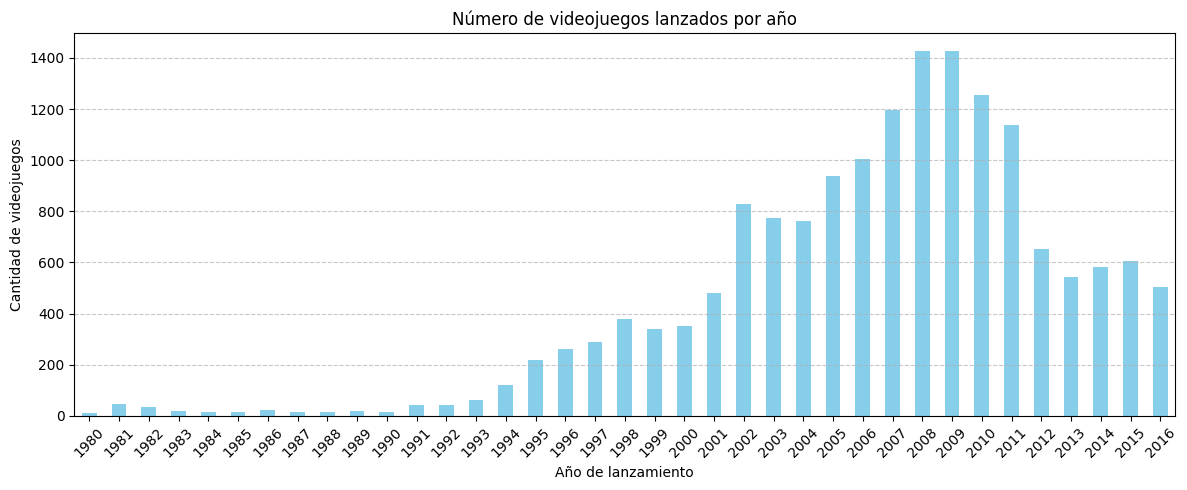

In [35]:
# Obtener la tabla dinámica games_per_year
games_per_year.plot(x = 'year_of_release', y = 'games_per_year', kind = 'bar', figsize = (12, 5), color ='skyblue', legend = False)

# Agregar un título, xlabel, ylabel y luego graficar
plt.title('Número de videojuegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de videojuegos')
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle='--', alpha = 0.7)
plt.tight_layout()
plt.show()

El análisis del número de videojuegos lanzados por año revela un crecimiento sostenido en la industria desde los años 90, alcanzando su punto máximo entre 2008 y 2009 con más de 1400 lanzamientos anuales. Esta tendencia refleja el auge de las consolas de séptima generación y el aumento del interés global por los videojuegos. A partir de 2010, se observa una disminución en la cantidad de lanzamientos, lo que podría estar relacionado con cambios en el modelo de negocio, la transición hacia plataformas digitales o una mayor concentración en desarrollos de alta calidad.

Veamos cómo variaron las ventas totales de videojuegos según la plataforma.

In [36]:
sales_per_platform = games.pivot_table(index = 'platform', values = 'total_sales', aggfunc = 'sum').sort_values(by = 'total_sales', ascending = False).reset_index()
display(sales_per_platform)

,platform,total_sales
0,PS2,1233.56
1,X360,961.24
2,PS3,931.34
3,Wii,891.18
4,DS,802.78
5,PS,727.58
6,PS4,314.14
7,GBA,312.88
8,PSP,289.53
9,3DS,257.81


Veamos cómo variaron las ventas totales de videojuegos según la plataforma. Las plataformas con mayores ventas son `PS2`, `Xbox 360`, `PS3`, `Wii`, `DS` y `PS`. Analicemos la distribución de ventas para cada una de estas plataformas según las ventas anuales.

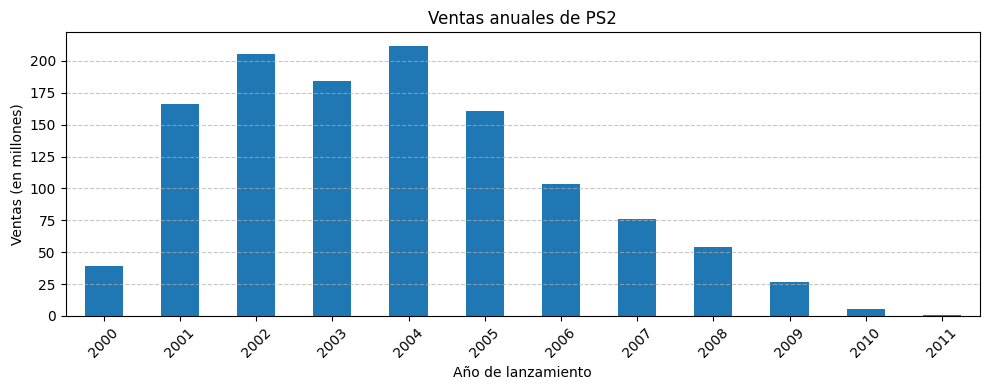

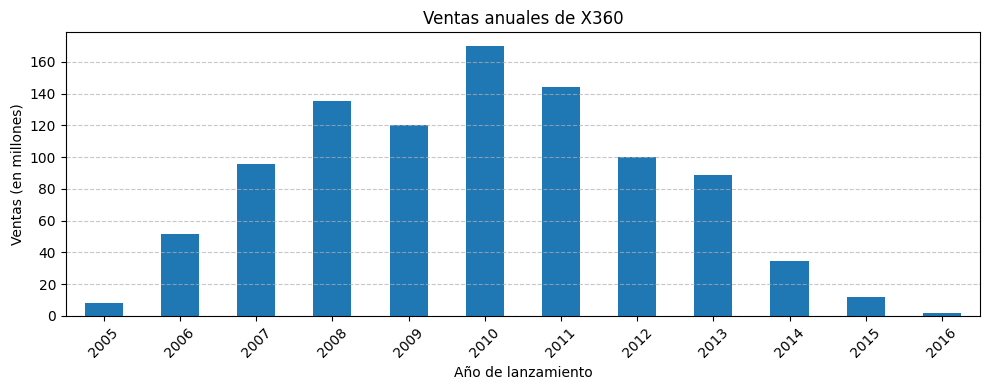

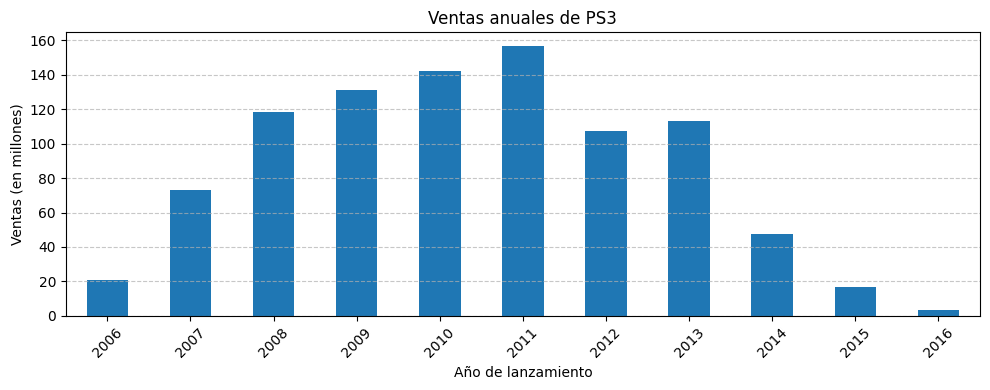

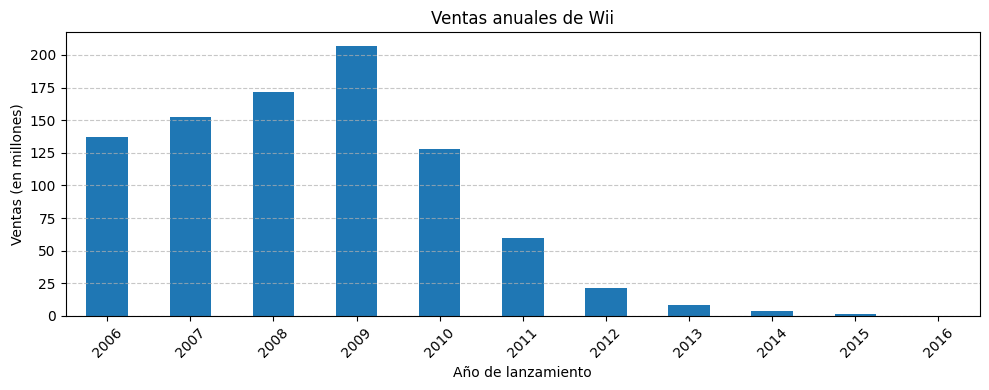

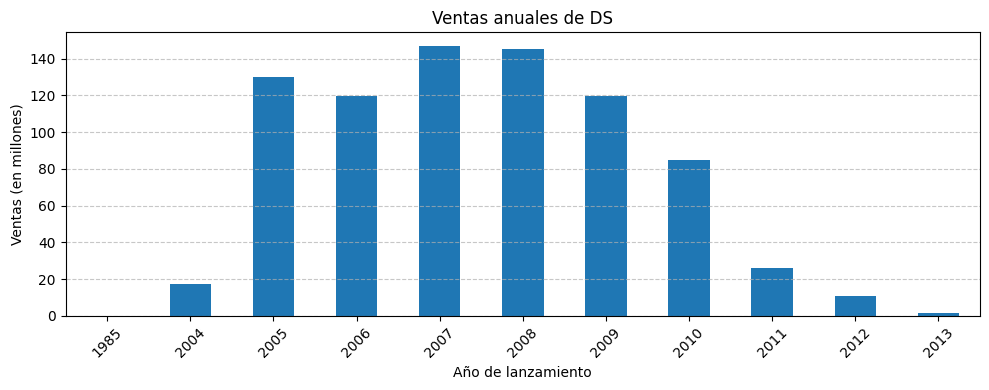

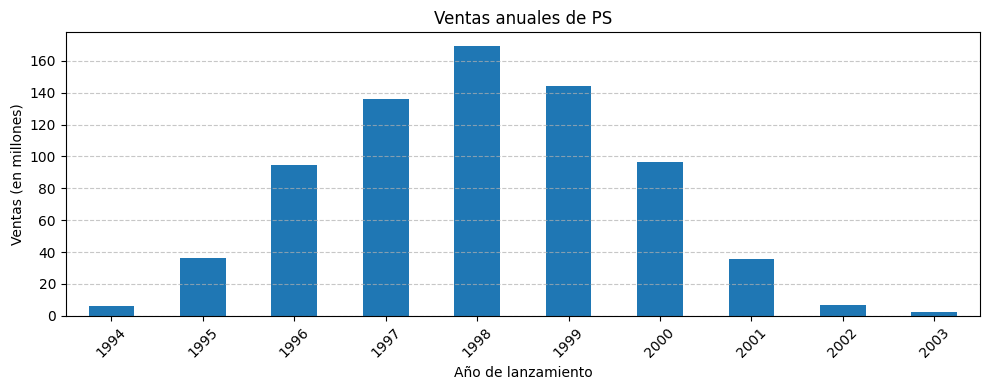

In [37]:
platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']

for platform in platforms:
    games[games['platform'] == platform].pivot_table(index = 'year_of_release', values = 'total_sales', aggfunc = 'sum').plot(
        kind = 'bar',
        figsize = (10, 4),
        legend = False
    )

    plt.title(f'Ventas anuales de {platform}')
    plt.xlabel('Año de lanzamiento')
    plt.ylabel('Ventas (en millones)')
    plt.xticks(rotation = 45)
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()
    plt.show()

Al analizar la evolución anual de ventas para las plataformas con mayores ingresos (PS2, Xbox 360, PS3, Wii, DS y PS), se observan patrones de comportamiento muy marcados. Cada consola tiene un período de auge bien definido, generalmente unos pocos años después de su lanzamiento, seguido por una disminución progresiva en las ventas.

Por ejemplo, la PS2 alcanza su punto máximo a principios de 1997, mientras que Xbox 360, Wii y PS3 muestran sus mejores resultados aproximadamente entre 2007 y 2011. La Nintendo DS tuvo un período prolongado de éxito, con ventas altas durante varios años seguidos. Estas tendencias reflejan los ciclos de vida típicos del hardware en la industria del videojuego, en los que cada consola atraviesa fases de introducción, crecimiento, madurez y declive.

Este análisis permite entender no solo qué plataformas fueron más exitosas en total, sino también cuándo lo fueron, lo cual es clave para estudios de mercado, decisiones comerciales y predicción de tendencias futuras.

Ahora observemos el comportamiento en los tres útlimos años de cada videojuego en cuanto a la ventas totales, es decir entre los años 2014 y 2016.

In [38]:
# Obtener un slice de datos llamado 'sample_data' que contiene todas las filas con valores de año de lanzamiento entre 2014 y 2016
sample_data = games[(games['year_of_release'] >= 2014) & (games['year_of_release'] <= 2016)]

In [39]:
# Agrupar el segmento de datos por plataforma y luego encuentrar las ventas globales totales para cada plataforma
sample_sales = sample_data.pivot_table(index = 'platform', values = 'total_sales', aggfunc = 'sum').sort_values(by = 'total_sales', ascending = False).reset_index()
display(sample_sales)

,platform,total_sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22
5,WiiU,42.98
6,PC,27.05
7,PSV,22.40
8,Wii,5.07
9,PSP,0.36


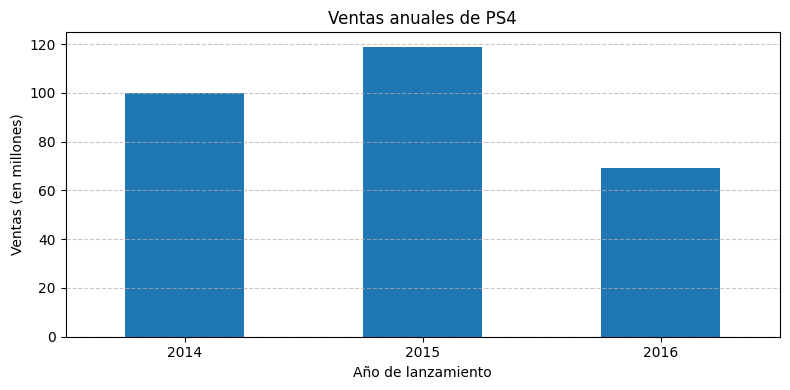

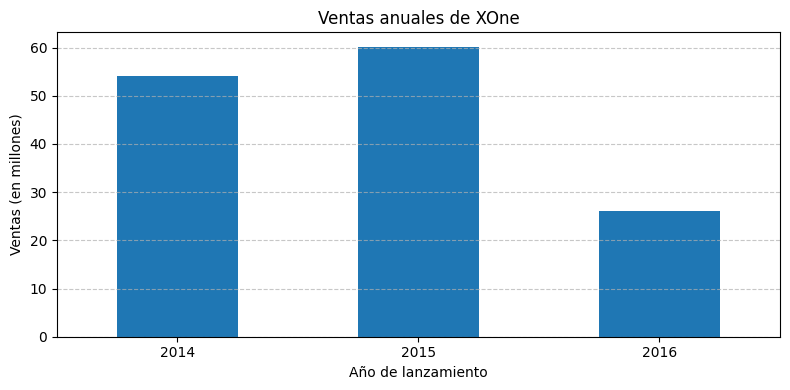

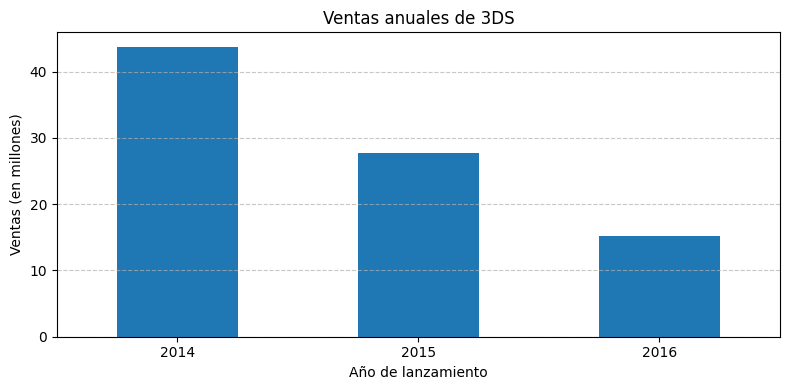

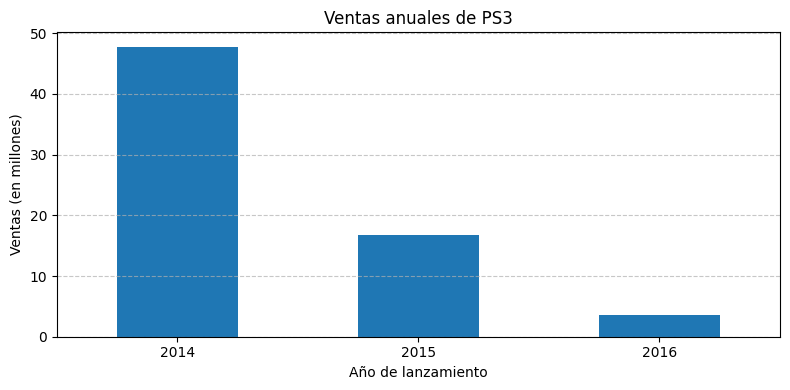

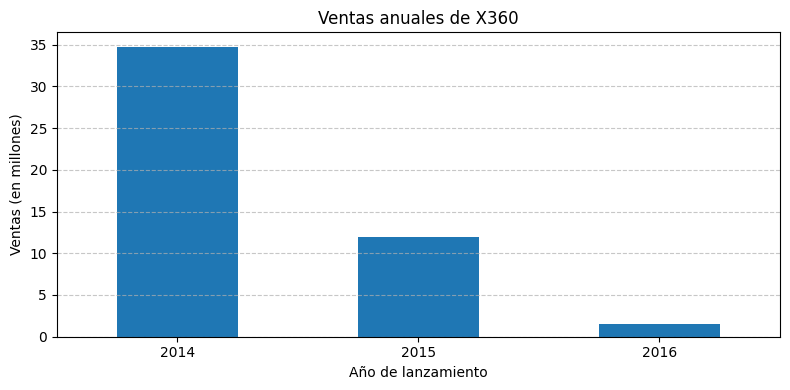

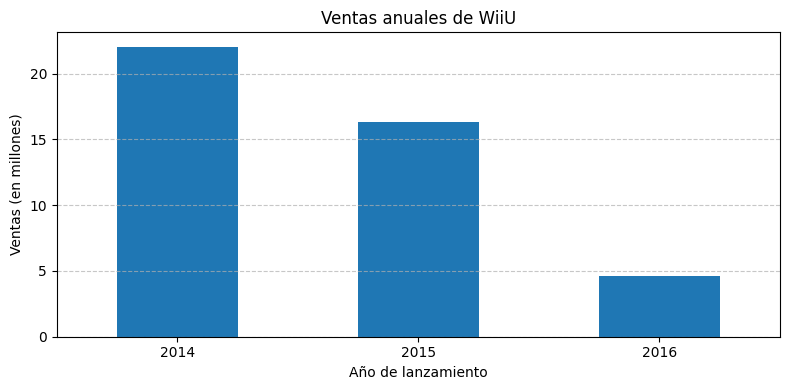

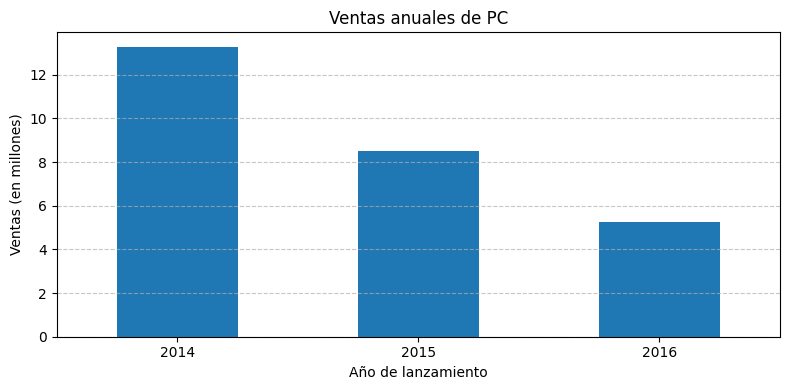

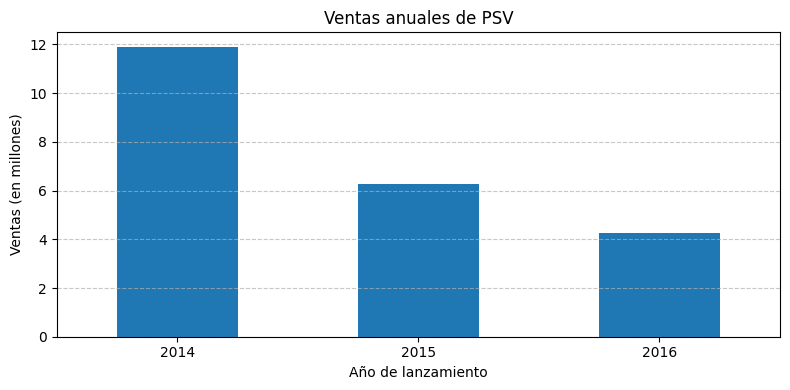

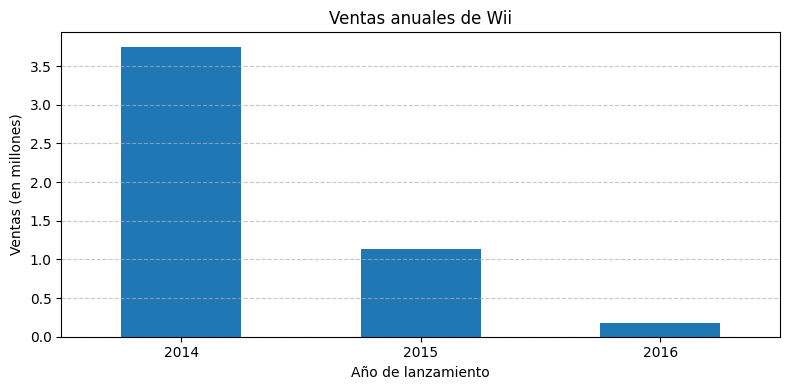

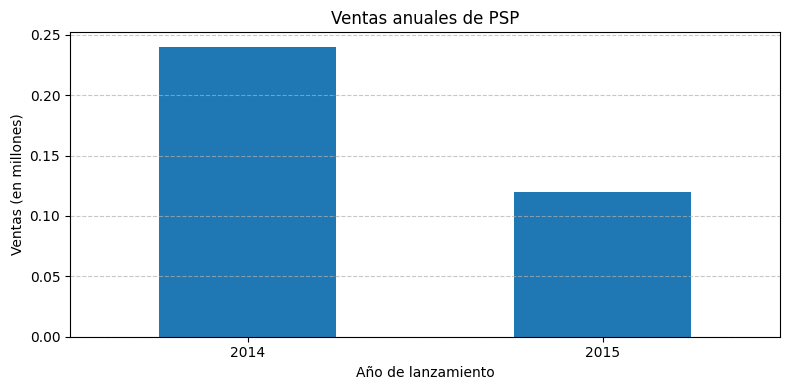

In [40]:
platforms = sample_sales['platform'].tolist()

for platform in platforms:
    sample_data[sample_data['platform'] == platform].pivot_table(index = 'year_of_release', values = 'total_sales', aggfunc = 'sum').plot(
        kind = 'bar',
        figsize = (8, 4),
        legend = False
    )
    
    plt.title(f'Ventas anuales de {platform}')
    plt.xlabel('Año de lanzamiento')
    plt.ylabel('Ventas (en millones)')
    plt.xticks(rotation = 0)
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()
    plt.show()

Al analizar las ventas por año para cada plataforma entre 2014 y 2016, se observa que muchas consolas ya estaban en fase de declive, con una clara disminución en sus ventas. Algunas plataformas como PS4 y XOne muestran un mejor desempeño, lo que corresponde a su reciente lanzamiento en ese periodo. Esto sugiere una transición generacional en el mercado de consolas, donde las plataformas más antiguas van perdiendo relevancia mientras que las nuevas comienzan a consolidarse.
Este análisis es clave para entender cómo evolucionan las plataformas a lo largo del tiempo y qué tan rápido cambian las preferencias de los consumidores en la industria de los videojuegos.

## Estudiar el comportamiento de los datos

Como se determinó en la sección anterior, las plataformas potencialmente rentables son PS4, Xbox One y PC. Obtendremos datos individuales sobre las ventas de videojuegos de cada plataforma y luego elaboraremos diagramas de caja para examinar visualmente su distribución. También analizaremos diagramas de caja para las plataformas 3DS, WiiU y PSV.

In [41]:
# Filtrar los datos de las plataformas seleccionadas 
selected_platforms = ['PS4', 'XOne', 'PC', '3DS', 'WiiU', 'PSV']
boxplot_data = sample_data[sample_data['platform'].isin(selected_platforms)]

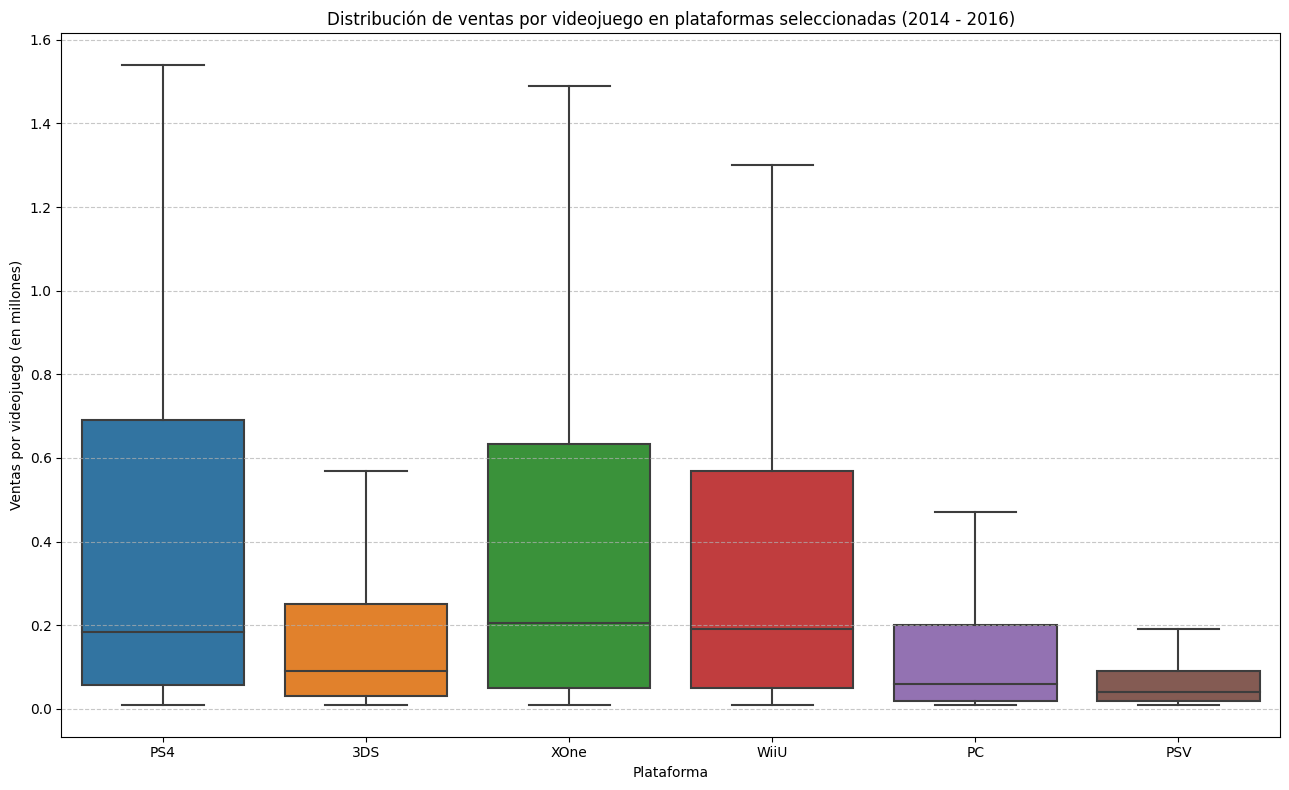

In [42]:
# Crear el diagrama de caja eliminando valores atípicos
plt.figure(figsize = (13, 8))
sns.boxplot(data = boxplot_data, x = 'platform', y = 'total_sales', showfliers  = False)

# Añadir títilos y estilo
plt.title('Distribución de ventas por videojuego en plataformas seleccionadas (2014 - 2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas por videojuego (en millones)')
plt.grid(axis = 'y', linestyle = '--', alpha=0.7)
plt.tight_layout()
plt.show()

El diagrama de caja anterior muestra la distribución de las ventas (`total_sales`) por videojuego en las plataformas seleccionadas entre 2014 y 2016, excluyendo los valores atípicos para facilitar una comparación más clara.
Se observa que PS4 y Xbox One tienen las medianas más altas de ventas por título, lo que confirma su posición como plataformas rentables durante ese período. La plataforma PC, aunque presenta menor mediana, tiene una distribución más amplia, indicando una mayor variabilidad en el desempeño de sus títulos.
Por otro lado, plataformas como 3DS, WiiU y PSV muestran medianas de ventas más bajas y rangos más estrechos, lo que sugiere una menor rentabilidad y menor dispersión en sus ventas por título.
Al eliminar los valores atípicos, este análisis se centra en el comportamiento más representativo de cada plataforma, evitando que unos pocos títulos extremadamente exitosos sesguen la interpretación general.

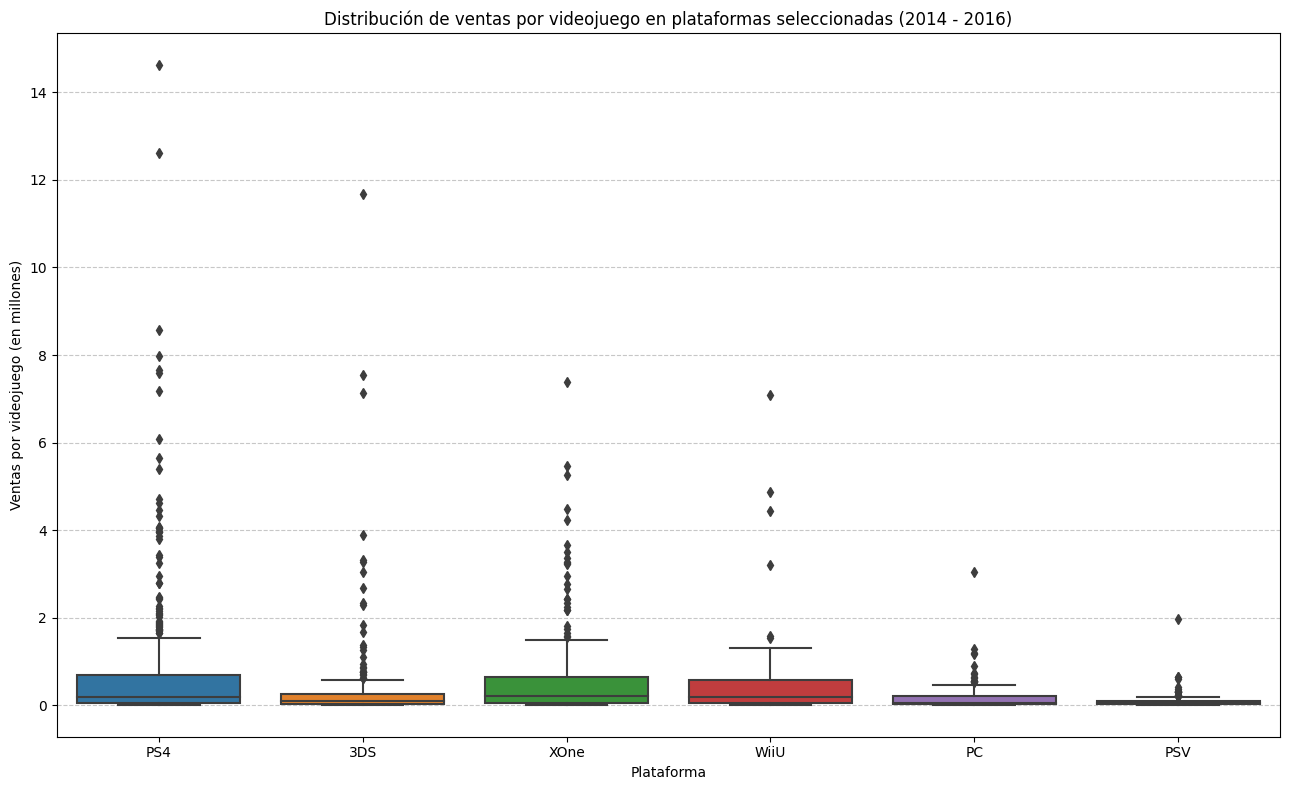

In [43]:
# Crear el diagrama de caja  sin eliminar valores atípicos
plt.figure(figsize = (13, 8))
sns.boxplot(data = boxplot_data, x = 'platform', y = 'total_sales')

# Añadir títilos y estilo
plt.title('Distribución de ventas por videojuego en plataformas seleccionadas (2014 - 2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas por videojuego (en millones)')
plt.grid(axis = 'y', linestyle = '--', alpha=0.7)
plt.tight_layout()
plt.show()

Analicemos también las ventas globales promedio de videojuegos para cada plataforma. Las compararemos con las medianas y veremos cómo difiere cada plataforma.

In [44]:
# Definir las plataformas seleccionadas
selected_platforms = ['PS4', 'XOne', 'PC', '3DS', 'WiiU', 'PSV']

# Filtrar los datos entre 20142016 y por plataformas de interés
filtered_data = games[games['platform'].isin(selected_platforms)]

# Calcular promedio y mediana de ventas por plataforma
platform_stats = filtered_data.groupby('platform')['total_sales'].agg(['mean', 'median']).reset_index()

platform_stats.columns = ['platform', 'average_sales', 'median_sales']

platform_stats['average_sales'] = platform_stats['average_sales'].round(2)
platform_stats['median_sales'] = platform_stats['median_sales'].round(2)

platform_stats = platform_stats.sort_values(by = 'average_sales', ascending = False)

display(platform_stats)

,platform,average_sales,median_sales
2,PS4,0.80,0.20
5,XOne,0.65,0.22
4,WiiU,0.56,0.22
0,3DS,0.50,0.12
1,PC,0.27,0.05
3,PSV,0.13,0.05


Las plataformas PS4, Xbox One y WiiU presentan ventas medianas relativamente altas, de aproximadamente 200,000 USD. En contraste, las plataformas PC, 3DS y PSV tienen medianas de ventas considerablemente más bajas: alrededor de 100,000 USD en el caso de PC y 3DS, y aproximadamente 50,000 USD para PSV.

Además, las plataformas PS4, Xbox One y WiiU muestran rangos de ventas mucho más amplios, especialmente hacia el extremo superior, lo que indica una mayor variabilidad en el rendimiento de sus títulos. Por el contrario, las plataformas PC, 3DS y PSV tienen distribuciones más compactas, con menos títulos sobresalientes.

En todos los casos, las ventas globales promedio por videojuego son significativamente superiores a las ventas medianas, lo que indica una distribución sesgada positivamente (derecha). Por ejemplo, en PS4, mientras la mediana está cerca de 200,000 USD, la media asciende a 800,000 USD, es decir, cuatro veces más alta. Este patrón se repite en todas las plataformas debido a la presencia de outliers: títulos con ventas millonarias que elevan notablemente el promedio.

También es importante notar que el orden de las plataformas según su media de ventas no siempre coincide con el orden según su mediana. Por ejemplo, Xbox One puede tener una mediana similar a la de PS4, pero su media puede ser inferior debido a una menor cantidad de títulos extremadamente exitosos.

En conclusión, las plataformas con mayores ventas globales por videojuego, considerando tanto la mediana como la media, son PS4, Xbox One y WiiU.

## Reseñas de usuarios y profesionales

Veamos cómo las valoraciones de usuarios y críticos afectan las ventas totales de un videojuego. Para simplificar este análisis, analicemos los datos de una plataforma popular: Xbox One. Ya hemos obtenido datos de todos los videojuegos para Xbox One. En los siguientes bloques de código, se crearán diagramas de dispersión para comparar las valoraciones de usuarios y críticos con las ventas totales de cada videojuego. Además, se calculará el coeficiente de correlación de cada diagrama de dispersión para determinar si existe alguna relación.

### Efecto de 'user_score' vs 'total_sales' en XOne

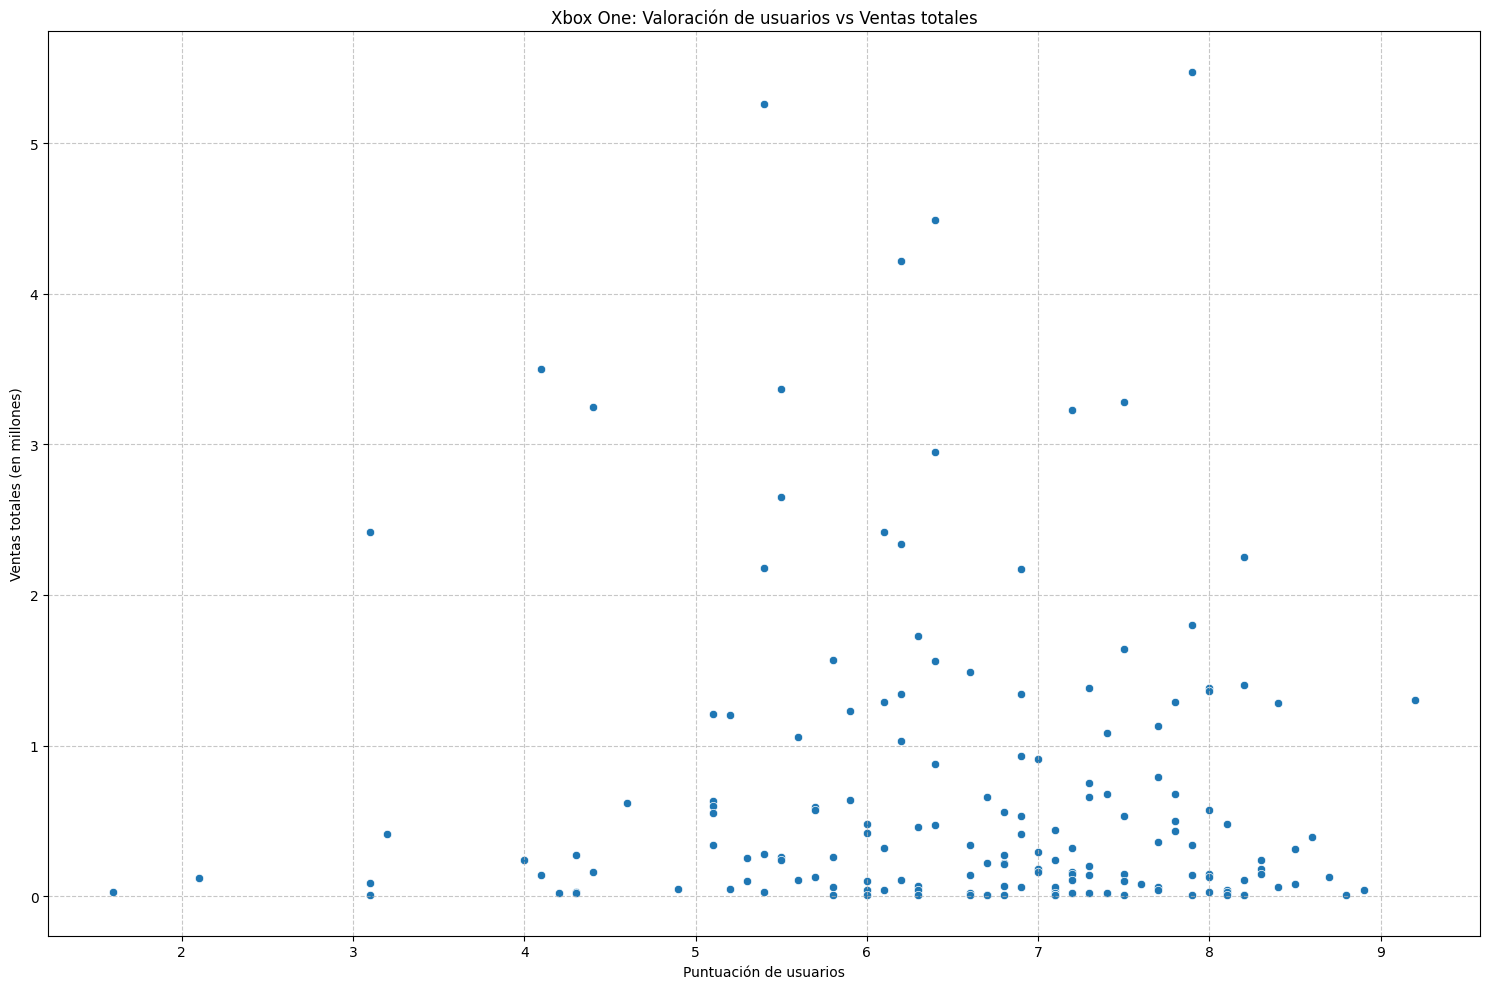

In [45]:
# 'user_score' de la plataforma Xbox One vs 'total_sales'
xone_data = sample_data.query("platform == 'XOne'")

plt.figure(figsize = (15, 10))
sns.scatterplot(data = xone_data, x = 'user_score', y = 'total_sales')

plt.title('Xbox One: Valoración de usuarios vs Ventas totales')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (en millones)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [46]:
# Calcular coeficiente de correlación entre 'user_score' y 'total_sales'
user_corr = xone_data['user_score'].corr(xone_data['total_sales'])
print(f"Coeficiente de correlación: {user_corr}")

Coeficiente de correlación: -0.0703839280647581


La correlación entre la valoración de los usuarios (`user_score`) y las ventas totales (`total_sales`) para videojuegos de la plataforma Xbox One en el período 2014 - 2016 fue de aproximadamente -0.07. Este valor indica una relación negativa muy débil, prácticamente nula.

Esto sugiere que las puntuaciones otorgadas por los usuarios no tuvieron un impacto significativo en el nivel de ventas de los videojuegos en ese período. Es probable que otros factores, como el marketing, la marca del juego, la publicidad o la presencia en medios, hayan influido más en las decisiones de compra que las valoraciones de los jugadores.

Además, esta débil correlación también puede reflejar que algunos títulos muy vendidos no necesariamente fueron bien recibidos por los usuarios, o que muchos juegos bien valorados no lograron alcanzar altos volúmenes de ventas.


### Efecto de 'critic_score' sobre 'total_sales' en XOne

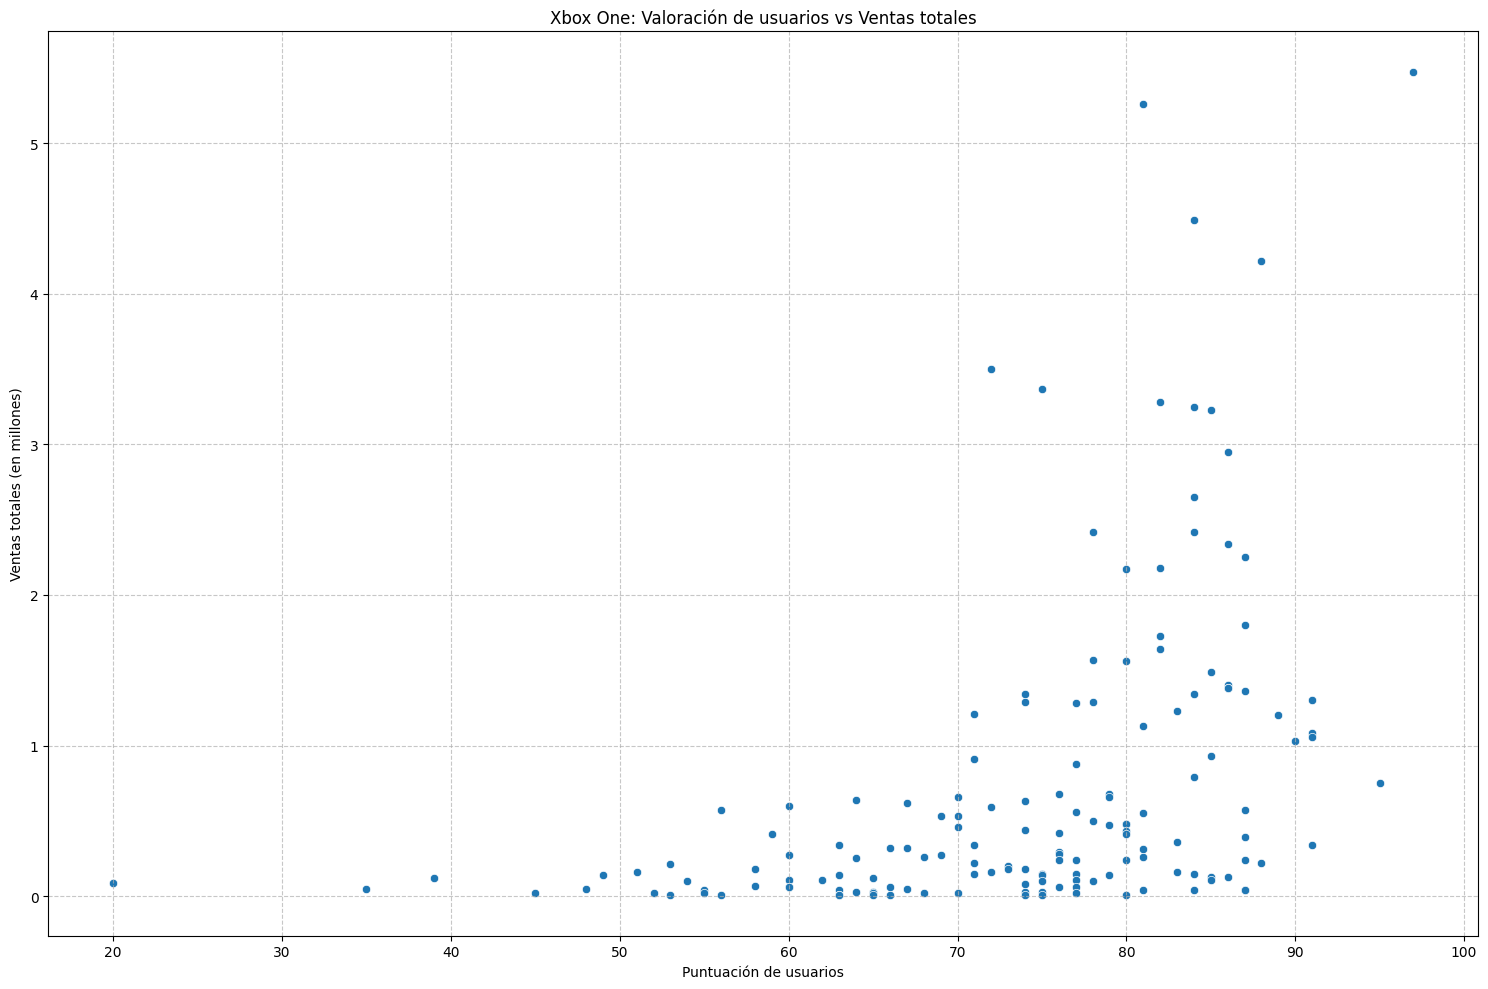

In [47]:
# 'critic_score' de la plataforma Xbox One vs 'total_sales'
xone_data = sample_data.query("platform == 'XOne'")

plt.figure(figsize = (15, 10))
sns.scatterplot(data = xone_data, x = 'critic_score', y = 'total_sales')

plt.title('Xbox One: Valoración de usuarios vs Ventas totales')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (en millones)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [48]:
# Calcular coeficiente de correlación entre 'critic_score' y 'total_sales'
user_corr = xone_data['critic_score'].corr(xone_data['total_sales'])
print(f"Coeficiente de correlación: {user_corr}")

Coeficiente de correlación: 0.42867694370333226


Al analizar la relación entre las valoraciones y las ventas totales de videojuegos para Xbox One entre 2014 y 2016, se observa lo siguiente:

- La correlación entre `user_score` y `total_sales` fue de aproximadamente -0.07, lo que indica una relación negativa muy débil, casi inexistente.
- En cambio, la correlación entre `critic_score` y `total_sales` fue de aproximadamente 0.40, lo cual representa una relación positiva moderada.

Esto sugiere que las valoraciones realizadas por los críticos tienen una mayor asociación con el rendimiento comercial de un videojuego que las valoraciones dadas por los usuarios. Es posible que las reseñas profesionales influyan más en la percepción pública y en la decisión de compra que las opiniones individuales de los jugadores.

También puede deberse a que los títulos más promocionados y esperados, que tienden a vender más, también son revisados más favorablemente por la crítica especializada.


### Efecto de 'user_score' vs 'total_sales' en PS4

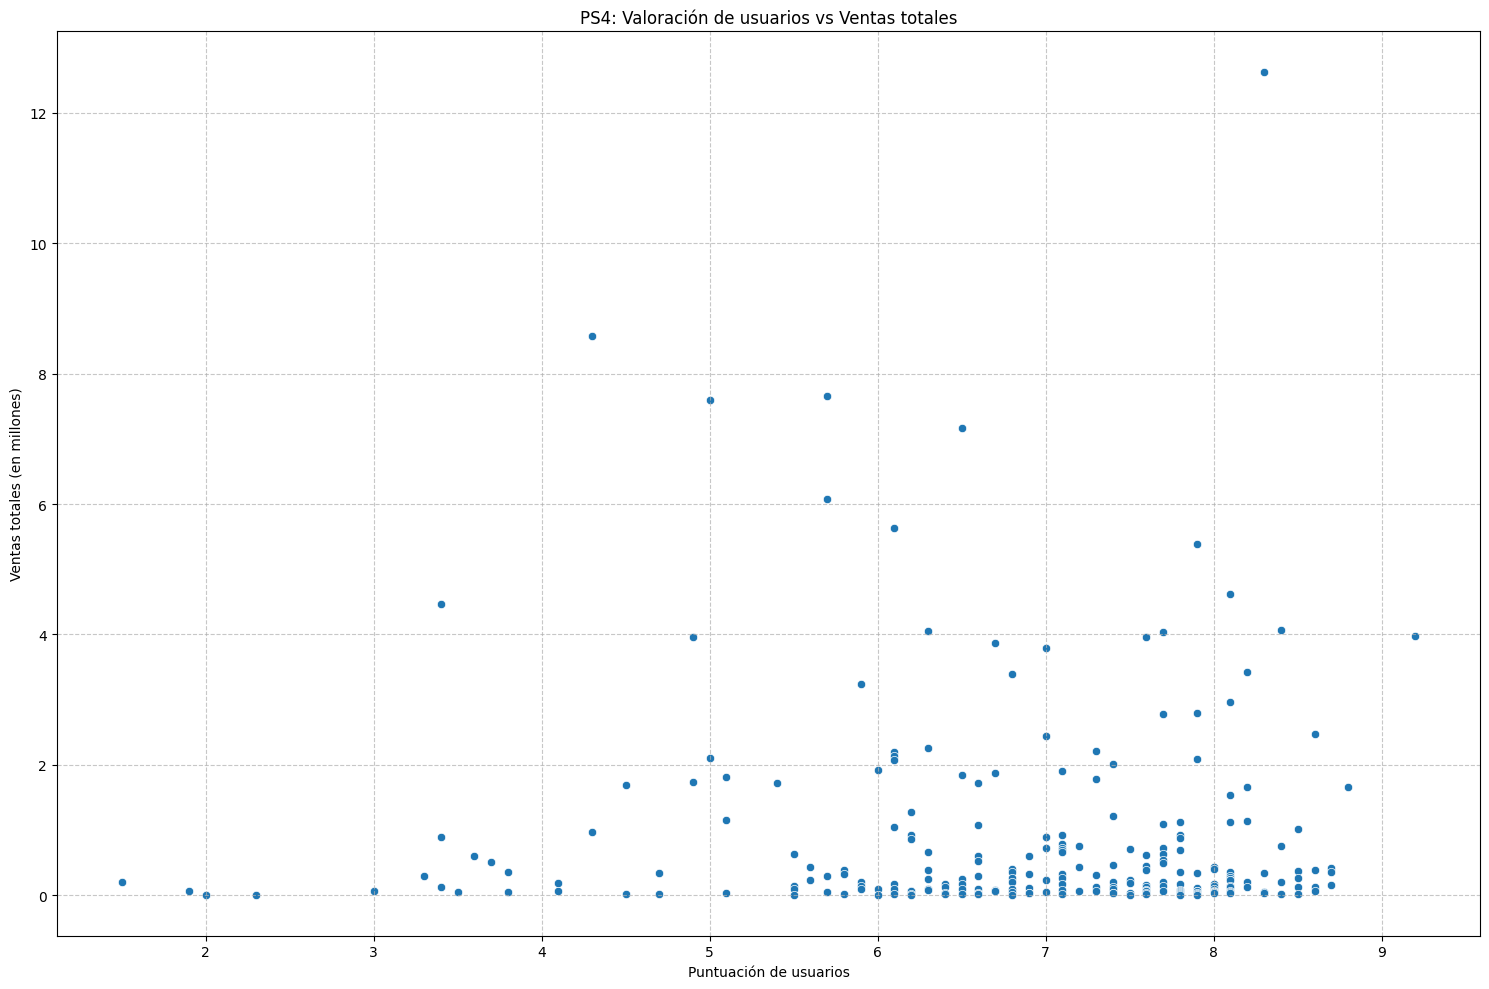

In [49]:
# 'user_score' de la plataforma PS4 vs 'total_sales'
ps4_data = sample_data.query("platform == 'PS4'")

plt.figure(figsize = (15, 10))
sns.scatterplot(data = ps4_data, x = 'user_score', y = 'total_sales')

plt.title('PS4: Valoración de usuarios vs Ventas totales')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (en millones)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [50]:
# Calcular coeficiente de correlación entre 'user_score' y 'total_sales'
user_corr = ps4_data['user_score'].corr(ps4_data['total_sales'])
print(f"Coeficiente de correlación: {user_corr}")

Coeficiente de correlación: -0.040131589472697356


En el caso de la plataforma PS4, la correlación entre las valoraciones de los usuarios (`user_score`) y las ventas totales (`total_sales`) fue de aproximadamente -0.04.

Este valor indica una relación negativa muy débil, prácticamente inexistente. En otras palabras, no se puede establecer una conexión clara entre las puntuaciones que otorgan los usuarios y el nivel de ventas de los videojuegos en esta plataforma durante el período 2014 - 2016.

Esto refuerza la conclusión previa observada con la plataforma Xbox One, donde también se encontró una correlación muy baja. Lo anterior sugiere que, al menos en estas plataformas, las valoraciones de los usuarios no son un buen predictor del éxito comercial de un videojuego.


### Efecto de 'critic_score' vs 'total_sales' en PS4

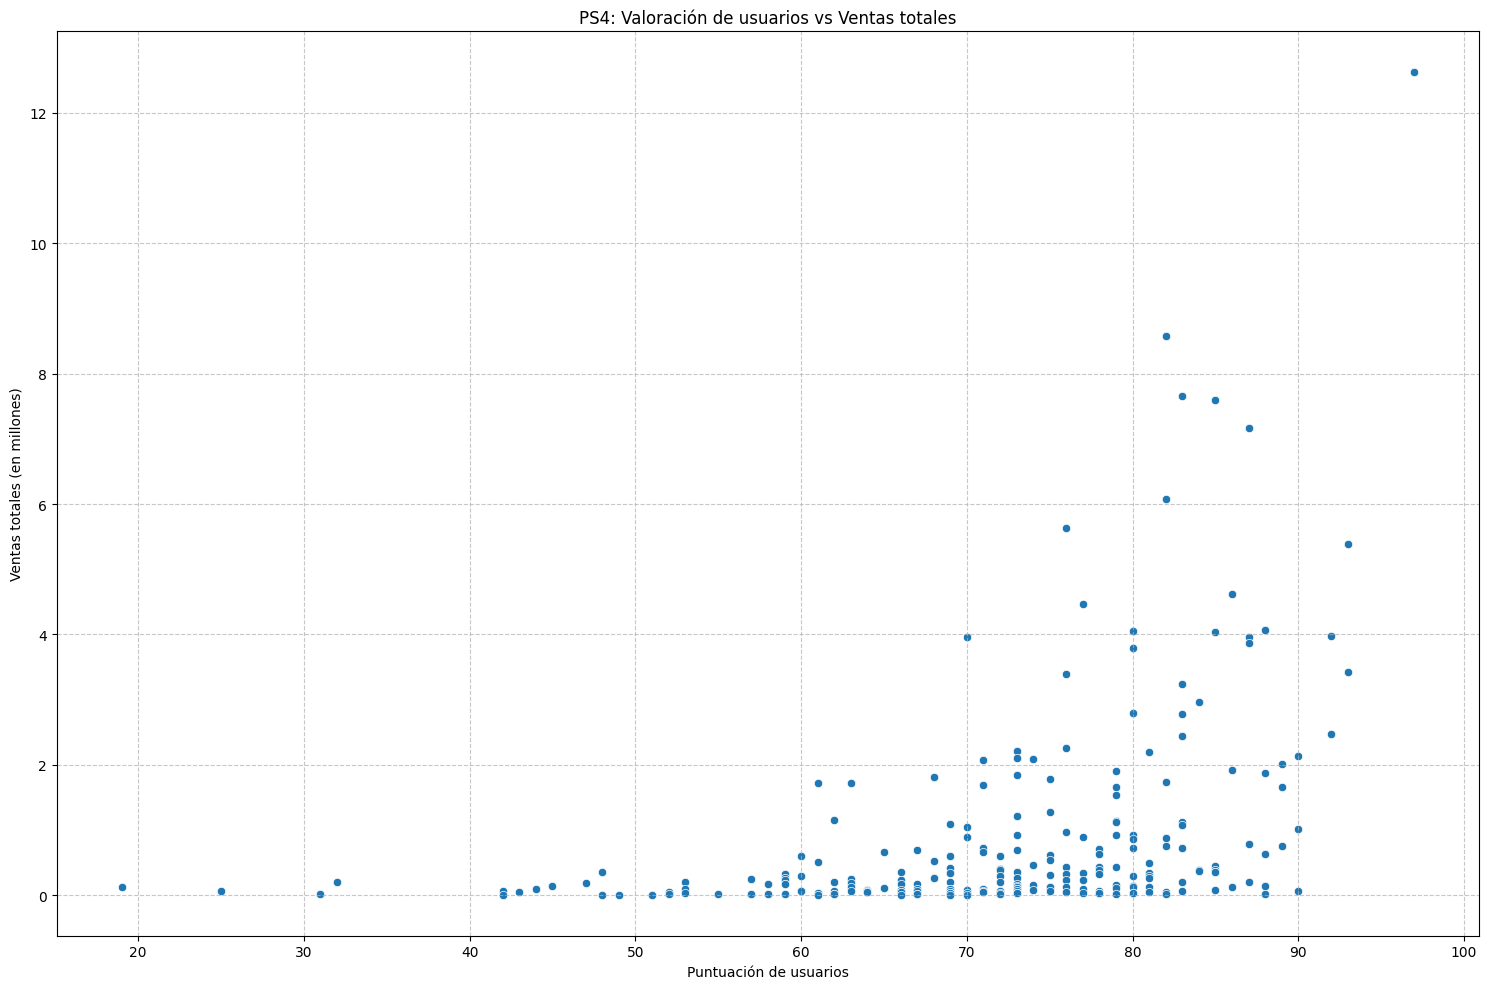

In [51]:
# 'critic_score' de la plataforma PS4 vs 'total_sales'
ps4_data = sample_data.query("platform == 'PS4'")

plt.figure(figsize = (15, 10))
sns.scatterplot(data = ps4_data, x = 'critic_score', y = 'total_sales')

plt.title('PS4: Valoración de usuarios vs Ventas totales')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (en millones)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [52]:
# Calcular coeficiente de correlación entre 'critic_score' y 'total_sales'
user_corr = ps4_data['critic_score'].corr(ps4_data['total_sales'])
print(f"Coeficiente de correlación: {user_corr}")

Coeficiente de correlación: 0.40266141068104083


Para los videojuegos de la plataforma PS4 lanzados entre 2014 y 2016, se obtuvieron los siguientes resultados al analizar la relación entre las valoraciones y las ventas totales:

- La correlación entre la valoración de los usuarios (`user_score`) y las ventas totales fue de aproximadamente -0.04, indicando una relación negativa muy débil y prácticamente inexistente.
- En contraste, la correlación entre la valoración de los críticos (`critic_score`) y las ventas totales fue de aproximadamente 0.40, lo que representa una relación positiva moderada.

Estos resultados sugieren que, para esta plataforma, las valoraciones de los críticos influyen más en el rendimiento comercial de un videojuego que las valoraciones de los usuarios. Al igual que en la plataforma Xbox One, los juegos mejor calificados por la crítica tienden a tener mejores ventas, aunque esta relación no es completamente determinante.

Es probable que la crítica profesional tenga mayor visibilidad o credibilidad al momento de influir en la decisión de compra de los consumidores, mientras que las opiniones de los usuarios pueden estar más fragmentadas o reflejar sesgos menos representativos del mercado.


## Distribución de juegos por género

Ahora veamos cómo se distribuyen los videojuegos entre géneros. En esta sección, dibujaremos dos gráficos de barras. Uno mostrará la cantidad de videojuegos en cada categoría de género y el otro la mediana de las ventas globales totales de videojuegos de cada categoría. Al comparar ambos gráficos, podremos obtener observaciones sobre los géneros rentables y su impacto en el futuro de los videojuegos.

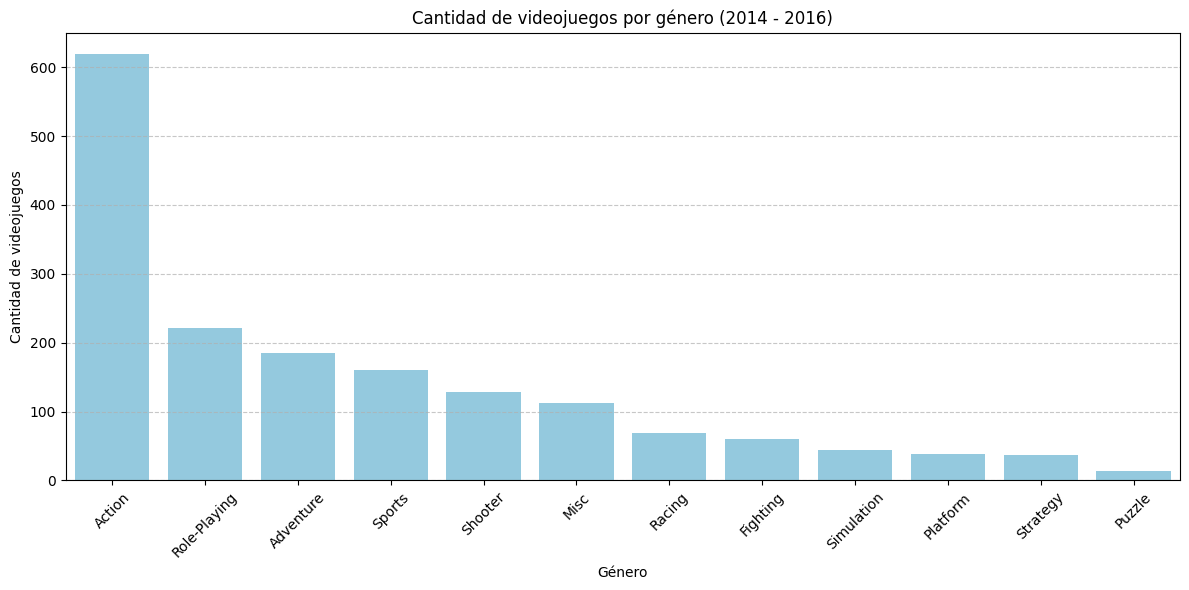

In [53]:
# Número de videojuegos por género en sample_data
genre_counts = sample_data['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

# Graficar el número total de juegos por género
plt.figure(figsize = (12, 6))
sns.barplot(data = genre_counts, x = 'genre', y = 'count', color = 'skyblue')
plt.title('Cantidad de videojuegos por género (2014 - 2016)')
plt.xlabel('Género')
plt.ylabel('Cantidad de videojuegos')
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

### Representación gráfica de las ventas totales medias por género

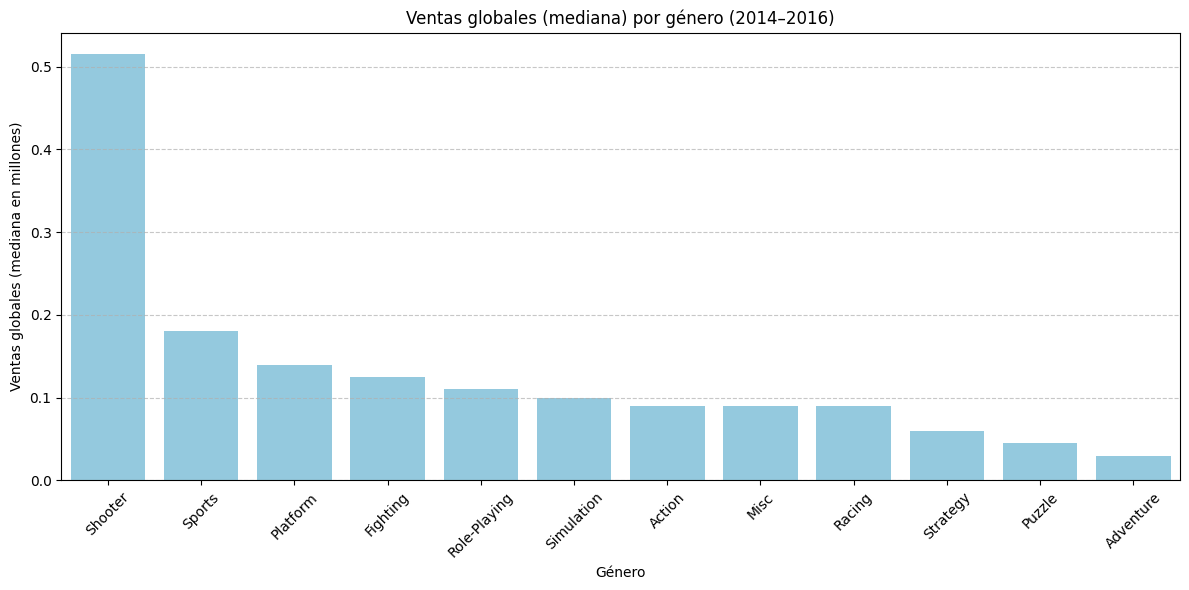

In [54]:
# Mediana de ventas globales por género en sample_data
genre_median_sales = sample_data.pivot_table(index = 'genre', values = 'total_sales', aggfunc = 'median').reset_index()
genre_median_sales = genre_median_sales.sort_values(by = 'total_sales', ascending = False)

# Gráfico
plt.figure(figsize = (12, 6))
sns.barplot(data = genre_median_sales, x = 'genre', y = 'total_sales', color = 'skyblue')
plt.title('Ventas globales (mediana) por género (2014–2016)')
plt.xlabel('Género')
plt.ylabel('Ventas globales (mediana en millones)')
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle='--', alpha = 0.7)
plt.tight_layout()
plt.show()

Entre los años 2014 y 2016, los géneros más representados en el mercado fueron Action, Role-Playing y Sports. Sin embargo, los géneros con mayores ventas globales medianas no siempre coincidieron con los más frecuentes.

Géneros como Shooter, Platform y Role-Playing mostraron ventas medianas más altas, lo que sugiere un buen desempeño comercial. En cambio, géneros con muchos títulos como Misc o Puzzle mostraron un desempeño más bajo en términos de ventas medianas.

Esto indica que la rentabilidad no depende exclusivamente de la cantidad de juegos lanzados en un género, sino también del interés del público y la calidad del producto. Estas conclusiones pueden guiar futuras decisiones sobre qué géneros priorizar en el desarrollo de videojuegos.


## Observando los atributos populares de los videojuegos en cada región

Ahora queremos tener una idea de qué tipo de plataformas, géneros de videojuegos y clasificaciones ESRB son más populares (tienen las mayores ventas) en cada una de las tres regiones (NA, EU, JP).

### Las cinco principales plataformas (ventas)

Analicemos las plataformas más populares de cada una de las tres regiones. Mediremos la popularidad de cada plataforma midiendo el nivel de ventas en cada región. En las celdas de código a continuación, se almacenará un segmento de datos que contiene las plataformas en las que se encuentra cada juego y las ventas regionales correspondientes. Luego, el segmento de datos se agrupará por nombre de plataforma, se sumarán las ventas regionales de cada plataforma y la tabla resultante se ordenará por región en orden descendente. Para facilitar la comprensión del lector, se resaltará la columna por la que se ordenan los datos.

Además, para visualizar los datos, se mostrará un gráfico de torta de las plataformas más populares de cada región. Se representarán las ventas regionales totales de las cinco plataformas más populares, y las plataformas restantes se agruparán en la categoría 'Otros'. Esto ofrecerá una representación de las plataformas más populares de cada región y una comparación de sus cuotas de mercado.

### Ventas en NA, UE, JP

In [55]:
# Crear subconjunto con las columnas de ventas de cada región
regional_data = sample_data[['platform', 'na_sales', 'eu_sales', 'jp_sales']]

In [56]:
# Agrupar y sumar ventas por plataforma para cada región
regional_sales = regional_data.groupby('platform', as_index = False).sum()

In [57]:
na_top = regional_sales.sort_values(by = 'na_sales', ascending = False).reset_index(drop = True)
display(na_top.style.highlight_max(subset = ['na_sales'], color = 'lightgreen'))

,platform,na_sales,eu_sales,jp_sales
0,PS4,98.610000,130.040000,15.020000
1,XOne,81.270000,46.250000,0.320000
2,X360,28.300000,15.490000,0.080000
3,3DS,22.640000,16.120000,44.240000
4,PS3,22.050000,25.540000,11.220000
5,WiiU,19.360000,13.150000,7.310000
6,PC,7.230000,17.970000,0.000000
7,PSV,2.520000,3.530000,14.540000
8,Wii,2.080000,2.590000,0.000000
9,PSP,0.000000,0.000000,0.360000


In [58]:
# Ordenar por cada región 
eu_top = regional_sales.sort_values(by = 'eu_sales', ascending = False).reset_index(drop = True)
display(eu_top.style.highlight_max(subset = ['eu_sales'], color = 'lightblue'))

,platform,na_sales,eu_sales,jp_sales
0,PS4,98.610000,130.040000,15.020000
1,XOne,81.270000,46.250000,0.320000
2,PS3,22.050000,25.540000,11.220000
3,PC,7.230000,17.970000,0.000000
4,3DS,22.640000,16.120000,44.240000
5,X360,28.300000,15.490000,0.080000
6,WiiU,19.360000,13.150000,7.310000
7,PSV,2.520000,3.530000,14.540000
8,Wii,2.080000,2.590000,0.000000
9,PSP,0.000000,0.000000,0.360000


In [59]:
jp_top = regional_sales.sort_values(by = 'jp_sales', ascending = False).reset_index(drop = True)
display(jp_top.style.highlight_max(subset = ['jp_sales'], color = 'lightpink'))

,platform,na_sales,eu_sales,jp_sales
0,3DS,22.640000,16.120000,44.240000
1,PS4,98.610000,130.040000,15.020000
2,PSV,2.520000,3.530000,14.540000
3,PS3,22.050000,25.540000,11.220000
4,WiiU,19.360000,13.150000,7.310000
5,PSP,0.000000,0.000000,0.360000
6,XOne,81.270000,46.250000,0.320000
7,X360,28.300000,15.490000,0.080000
8,PC,7.230000,17.970000,0.000000
9,Wii,2.080000,2.590000,0.000000


In [60]:
# Función para graficar las plataformas más populares
def plot_top_platforms_pie(data, region, top_n = 5):
    # Ordenar por región
    data_sorted = data.sort_values(by = region, ascending = False)

    # Tomar las plataformas principales
    top_platforms = data_sorted.head(top_n)
    other_sales = data_sorted[region].iloc[top_n:].sum()

    # Etiquetas y valores
    labels = top_platforms['platform'].tolist() + ['Otros']
    sizes = top_platforms[region].tolist() + [other_sales]

    # Gráfico
    plt.figure(figsize = (8, 6))
    plt.pie(sizes, labels = labels, autopct = '%1.1f%%', startangle = 140, colors = sns.color_palette('pastel'))
    plt.title(f'Participación de mercado por plataforma en {region.upper()} (2014 - 2016)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

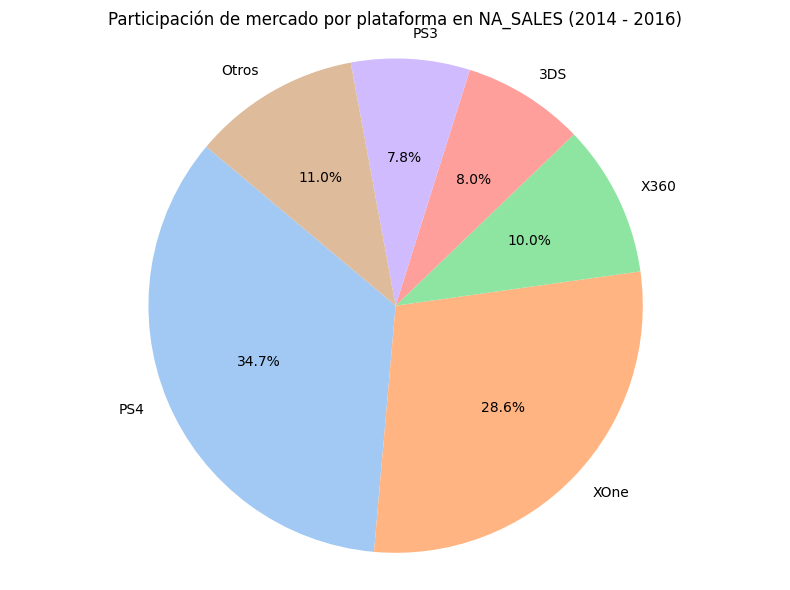

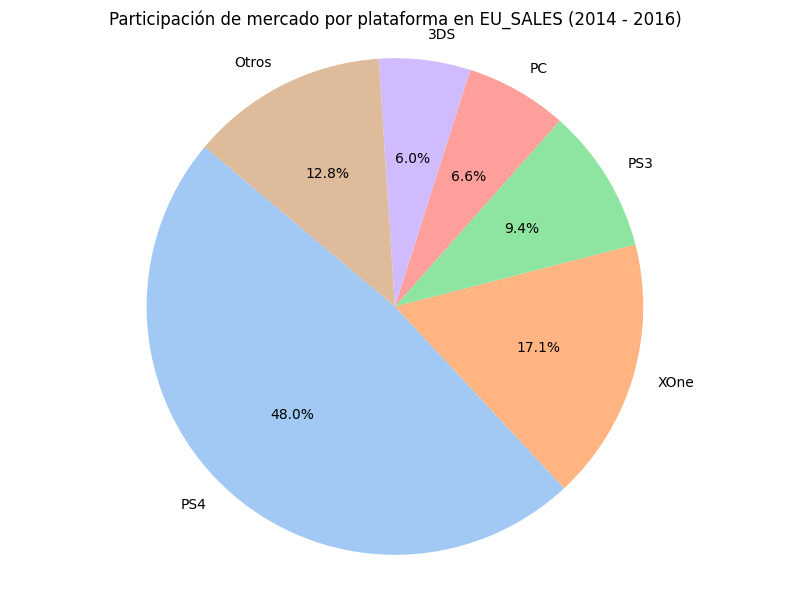

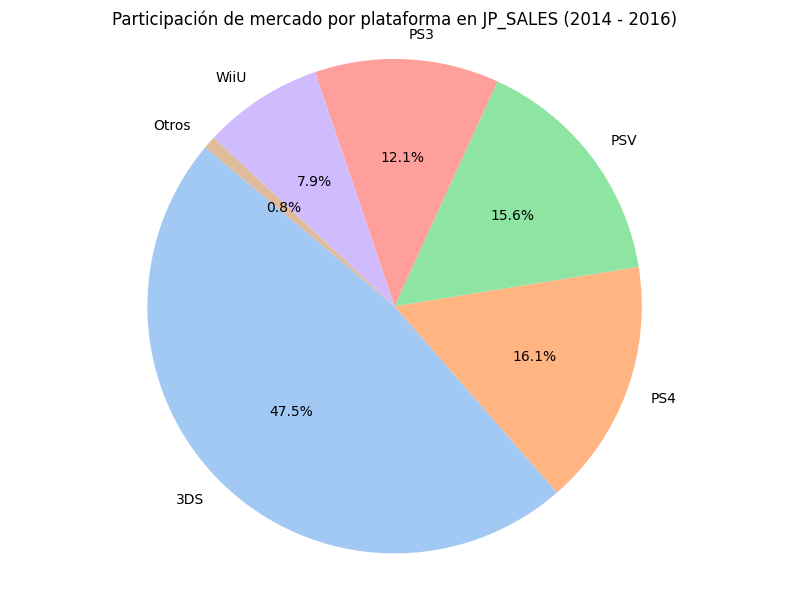

In [61]:
# Llamar cada región a la función para graficar
plot_top_platforms_pie(regional_sales, 'na_sales')
plot_top_platforms_pie(regional_sales, 'eu_sales')
plot_top_platforms_pie(regional_sales, 'jp_sales')

El análisis de las plataformas más populares en cada región entre los años 2014 y 2016 revela diferencias claras en el comportamiento del mercado según la ubicación geográfica. Al observar las ventas totales por región y representarlas gráficamente, se evidencian preferencias muy distintas entre los jugadores de Norteamérica, Europa y Japón.

Norteamérica muestra un mercado altamente competitivo, con la PS4 y Xbox One dominando la mayor parte de las ventas regionales. La fuerte presencia de Xbox One en esta región es consistente con el hecho de que Microsoft, su desarrollador, tiene una base sólida en el mercado estadounidense. A estas consolas las acompaña la Nintendo 3DS, lo que demuestra que las consolas portátiles también lograron mantenerse relevantes en este mercado.

En Europa, la situación es similar, aunque con una clara inclinación hacia la PS4, que encabeza las ventas con una ventaja más amplia. La Xbox One también mantiene un buen rendimiento, pero con menor protagonismo que en Norteamérica. La 3DS sigue figurando entre las plataformas más vendidas, aunque su cuota de mercado es menor. Esta región parece preferir plataformas de consola de salón por encima de las portátiles, lo cual podría relacionarse con hábitos de juego domésticos más extendidos.

Por otro lado, Japón presenta un panorama completamente distinto. Las plataformas portátiles dominan las ventas, con la Nintendo 3DS y la PlayStation Vita liderando con claridad. En esta región, las consolas de sobremesa como la Xbox One tienen una participación casi nula, reflejando una preferencia muy arraigada por dispositivos portátiles, posiblemente debido a los estilos de vida urbanos y la alta movilidad de la población. Incluso la PS4, que en Occidente domina ampliamente, ocupa un lugar más modesto en comparación.

Una plataforma exitosa en América o Europa puede no tener el mismo impacto en Japón, y viceversa. Entender estos patrones es esencial para que las compañías desarrolladoras maximicen sus oportunidades comerciales y lleguen efectivamente a su audiencia objetivo.

### Los cinco géneros más vendidos

Veamos qué géneros tienen mayores ventas en cada región.

In [62]:
# Agrupar por género y sumar las ventas en cada región
genre_sales = sample_data.groupby('genre', as_index = False)[['na_sales', 'eu_sales', 'jp_sales']].sum()

In [63]:
# Crear una función para el grafico de torta por región
def plot_top_genres_pie(data, region_column, region_name, top_n = 6):
    # Ordenar por ventas en la región específica
    data_sorted = data.sort_values(by = region_column, ascending = False)

    # Tomar los géneros más vendidos
    top_genres = data_sorted.head(top_n)
    other_sales = data_sorted[region_column].iloc[top_n:].sum()

    # Etiquetas y valores
    labels = top_genres['genre'].tolist() + ['Otros']
    sizes = top_genres[region_column].tolist() + [other_sales]

    # Gráfico
    plt.figure(figsize = (8, 6))
    plt.pie(sizes, labels = labels, autopct = '%1.1f%%', startangle = 140, colors = sns.color_palette('pastel'))
    plt.title(f'Participación de ventas por género en {region_name} (2014 - 2016)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

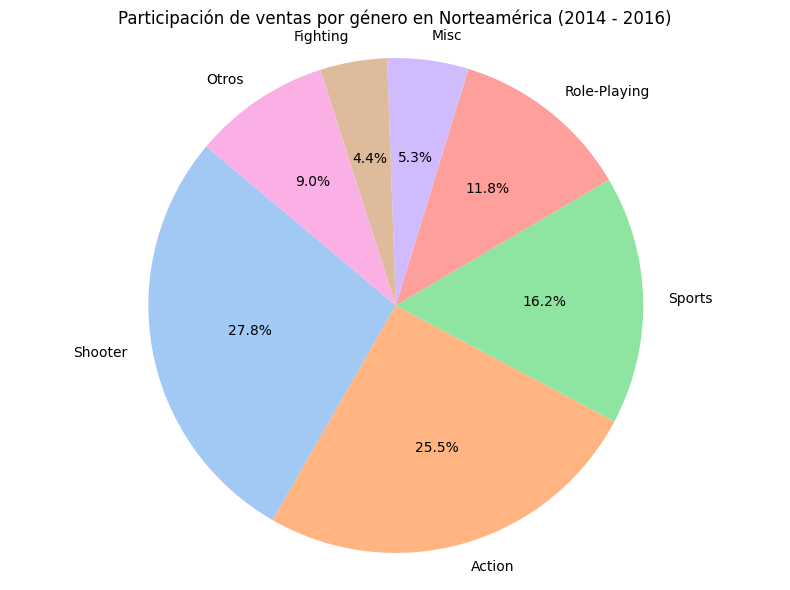

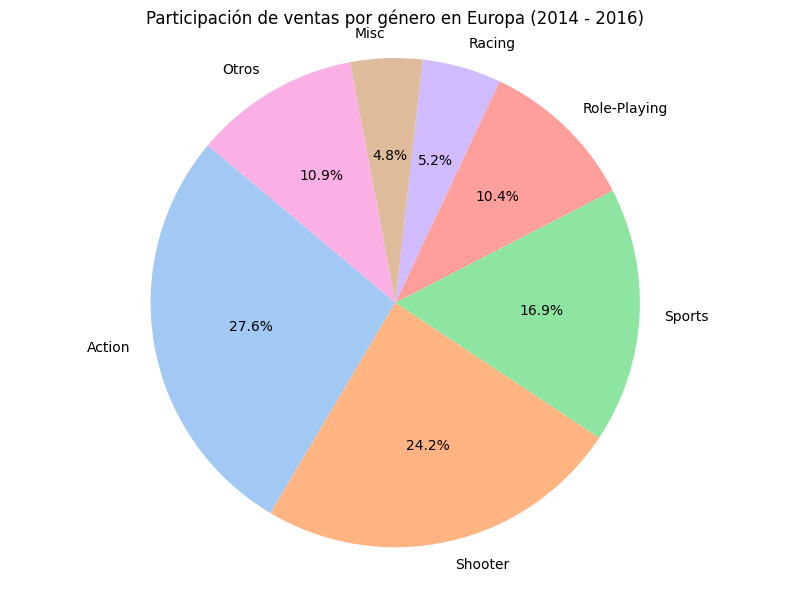

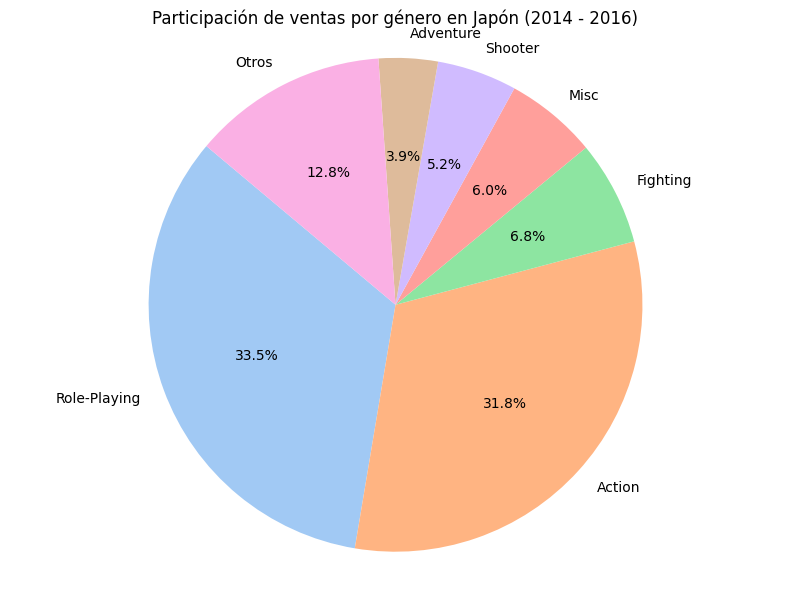

In [64]:
# Graficar por cada región
plot_top_genres_pie(genre_sales, 'na_sales', 'Norteamérica')
plot_top_genres_pie(genre_sales, 'eu_sales', 'Europa')
plot_top_genres_pie(genre_sales, 'jp_sales', 'Japón')

El análisis de ventas por género entre 2014 y 2016 muestra diferencias claras entre regiones:

- En Norteamérica, los géneros más populares fueron Action, Shooter y Sports, reflejando una fuerte preferencia por juegos competitivos y dinámicos.
- En Europa, aunque también dominan Action y Sports, la distribución es más equilibrada con una participación relevante del género Role-Playing.
- En Japón, el género Role-Playing lidera con claridad, seguido por Action y Adventure, mostrando una marcada preferencia por experiencias narrativas y tradicionales.

### Las mejores clasificaciones de ESRB

Determinemos si las clasificaciones ESRB de los videojuegos tienen algún efecto en las ventas regionales.

In [65]:
# Agrupar y sumar ventas por rating
rating_sales = sample_data.groupby('rating', as_index=False)[['na_sales', 'eu_sales', 'jp_sales']].sum()

In [66]:
# Crear función para gráfico de torta para rating
def plot_top_ratings_pie(data, region_column, region_name, top_n = 5):
    # Ordenar por ventas en la región específica
    data_sorted = data.sort_values(by = region_column, ascending = False).head(top_n)

    # Etiquetas y valores
    labels = data_sorted['rating'].tolist()
    sizes = data_sorted[region_column].tolist()

    # Gráfico
    plt.figure(figsize=(8, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title(f'Participación de ventas por clasificación ESRB en {region_name} (2014 - 2016)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

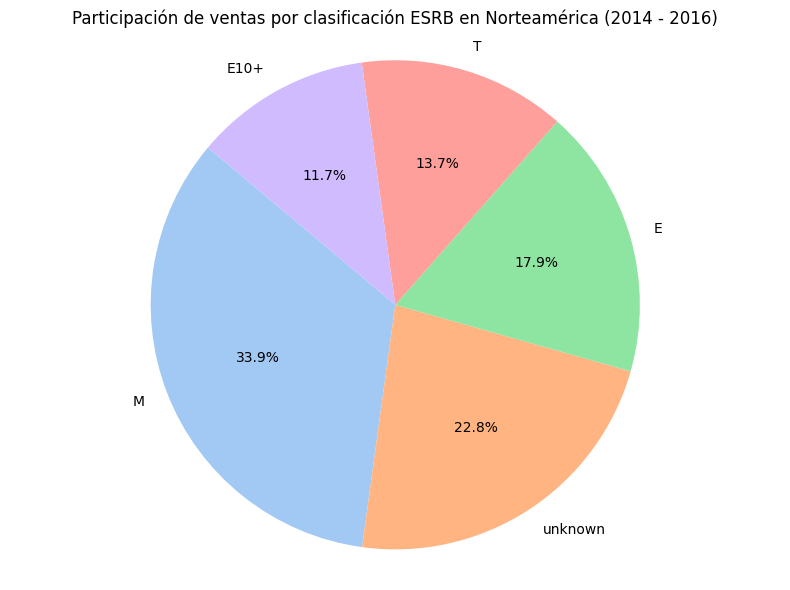

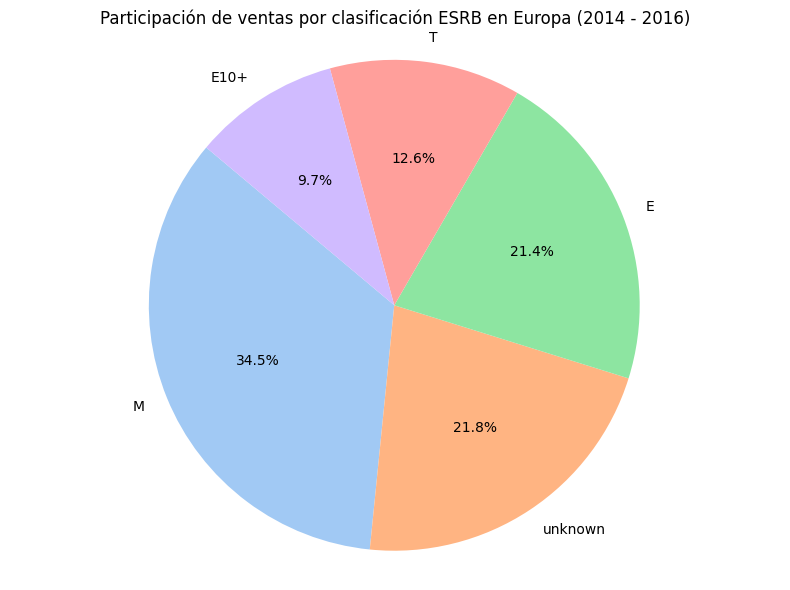

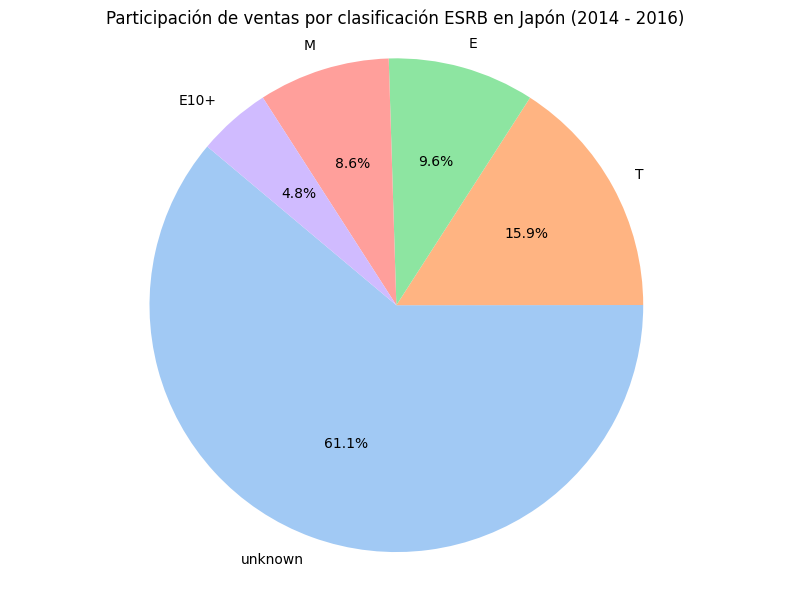

In [67]:
# Llamar la función para generar los gráficos por región
plot_top_ratings_pie(rating_sales, 'na_sales', 'Norteamérica')
plot_top_ratings_pie(rating_sales, 'eu_sales', 'Europa')
plot_top_ratings_pie(rating_sales, 'jp_sales', 'Japón')

Tanto Norteamérica como Europa presentan distribuciones de ventas muy similares en relación con las clasificaciones ESRB. En ambas regiones, los videojuegos con clasificación M (Mature) son responsables de la mayor proporción de ventas, representando aproximadamente un tercio del total. Les siguen los videojuegos con clasificación E (Everyone), que abarcan entre 18 % y 20 % de las ventas, y los juegos T (Teen), con alrededor del 13 %. Los juegos E10+ también tienen presencia, con una participación que oscila entre el 10 % y 12 %.

Cabe destacar que cerca del 22 % de los juegos en ambas regiones no tienen una clasificación disponible en el dataset, debido a que están marcados como RP (Rating Pending). Esto limita la interpretación completa de la distribución.

En Japón, la situación es muy distinta. Más del 60 % de las ventas corresponden a videojuegos sin una clasificación ESRB registrada (RP), lo que complica cualquier análisis concluyente. Entre las clasificaciones visibles, T (Teen) lidera con cerca del 16 %, una cifra similar a la observada en las otras regiones. Sin embargo, las clasificaciones E (Everyone) y E10+ tienen una representación más baja en comparación con Norteamérica y Europa. Particularmente notable es la clasificación M, que en Japón solo representa alrededor del 9 % de las ventas, contrastando fuertemente con el alto desempeño de esta categoría en las otras regiones.

Con base en estos datos, se sugiere que Ice concentre sus lanzamientos en videojuegos con clasificación M y T para Norteamérica y Europa, mientras que en Japón sería más adecuado enfocarse en juegos con clasificación T y E.

## Prueba de las siguientes hipótesis

Tras analizar los datos anteriores, probemos dos hipótesis. La primera hipótesis es que las valoraciones promedio de los usuarios para los videojuegos de Xbox One y PC son las mismas, y la segunda hipótesis es que las valoraciones promedio de los usuarios para los videojuegos de acción y deportes son diferentes.

### Probar si las calificaciones promedio de los usuarios de las platafomras de Xbox One y PC son las mismas


Antes de aplicar la prueba t para comparar las calificaciones promedio de los usuarios entre plataformas, es importante verificar si las varianzas de ambas muestras son iguales. Para ello, utilizamos la prueba de Levene, que evalúa si dos grupos tienen varianzas similares.

La hipótesis nula de la prueba de Levene afirma que las varianzas de ambas muestras son iguales.
La hipótesis alternativa indica que las varianzas son diferentes.

Para interpretar el resultado:

- Si el valor p es menor que 0.05, rechazamos la hipótesis nula, lo que significa que las varianzas no son iguales, y debemos usar equal_var=False en la prueba t.

- Si el valor p es mayor o igual que 0.05, no podemos rechazar la hipótesis nula, lo que indica que las varianzas son iguales, y podemos usar equal_var = True.

In [68]:
# Prueba de Levene

# Obtener las calificaciones de usuario para Xbox One y PC, sin valores faltantes
xone_ratings = sample_data.query("platform == 'XOne'")['user_score'].dropna()
pc_ratings = sample_data.query("platform == 'PC'")['user_score'].dropna()

alpha = 0.05

# Prueba de Levene para comparar varianzas
levene = st.levene(xone_ratings, pc_ratings)
levene_pvalue = levene.pvalue

print('Resultado de la prueba de Levene:')
print(f'Valor p: {levene_pvalue}')

# Determinar el valor de equal_var
if levene_pvalue < alpha:
    print('Rechazamos la hipótesis nula: las varianzas no son iguales. ')
    equal_var = False
else:
    print('No podemos rechazar la hipótesis nula: las varianzas son iguales.')
    equal_var = True

Resultado de la prueba de Levene:
Valor p: 0.014868430917663678
Rechazamos la hipótesis nula: las varianzas no son iguales. 


Para comprobar si las calificaciones promedio otorgadas por los usuarios a los videojuegos son iguales entre las plataformas Xbox One y PC, se realizará una prueba t de Student para muestras independientes. Esta prueba estadística permite comparar las medias de dos grupos distintos y determinar si la diferencia entre ellas es significativa desde el punto de vista estadístico. En este caso, se trabajará con los datos comprendidos entre los años 2014 y 2016.

La hipótesis nula establece que las calificaciones promedio de los usuarios para Xbox One y PC son iguales. Por otro lado, la hipótesis alternativa plantea que las calificaciones promedio son diferentes entre ambas plataformas. Para tomar una decisión, se utilizará un nivel de significancia de 0.05. Si el valor-p obtenido es menor que 0.05, se rechazará la hipótesis nula y se concluirá que existe una diferencia significativa entre las calificaciones. En caso contrario, no se rechazará la hipótesis nula, lo que indica que no hay evidencia suficiente para afirmar que las calificaciones promedio son distintas.

In [69]:
# Obtener calificaciones de usuarios para Xbox One y PC usando query
xone_ratings = sample_data.query("platform == 'XOne'")['user_score'].dropna()
pc_ratings = sample_data.query("platform == 'PC'")['user_score'].dropna()

alpha = 0.05

results = st.ttest_ind(xone_ratings, pc_ratings, equal_var = False)

print('Valor p:', results.pvalue)

# Evaluar la hipótesis
if (results.pvalue < alpha):
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Valor p: 0.11601398086668832
No podemos rechazar la hipótesis nula


Después de realizar una prueba t de Student para comparar las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC, se obtuvo un valor p de 0.116. Dado que este valor es mayor al nivel de significancia de 0.05, no se puede rechazar la hipótesis nula. Esto sugiere que no hay diferencias estadísticamente significativas en las calificaciones promedio de los usuarios entre ambas plataformas en el periodo considerado. Por lo tanto, se puede asumir que las valoraciones promedio de los usuarios para videojuegos en Xbox One y PC son similares.

### Probar si las calificaciones promedio de los usuarios para los géneros de acción y deportes son diferentes

Siguiendo el mismo principio de la hipótesis anterior, se realiza la prueba de Levene como complemento de la prueba t de Student. Esta prueba permite determinar si las varianzas de las dos muestras (en este caso, las calificaciones de los géneros Action y Sports) son iguales o no. El resultado de la prueba de Levene se utiliza para establecer correctamente el valor del parámetro equal_var en la prueba t. Así garantizamos que la comparación entre las medias se realiza de forma estadísticamente adecuada.

In [70]:
# Prueba de Levene

# Calificaciones de usuarios para los géneros Acción y Deportes
action_ratings = sample_data.query("genre == 'Action'")['user_score'].dropna()
sports_ratings = sample_data.query("genre == 'Sports'")['user_score'].dropna()

alpha = 0.05

# Prueba de Levene para comparar varianzas
levene = st.levene(action_ratings, sports_ratings)
levene_pvalue = levene.pvalue

print('Resultado de la prueba de Levene:')
print(f'Valor p: {levene_pvalue}')

# Determinar el valor de equal_var
if levene_pvalue < alpha:
    print('Rechazamos la hipótesis nula: las varianzas no son iguales.')
    equal_var = False
else:
    print('No podemos rechazar la hipótesis nula: las varianzas son iguales.')
    equal_var = True

Resultado de la prueba de Levene:
Valor p: 4.480161685830322e-06
Rechazamos la hipótesis nula: las varianzas no son iguales.


En esta hipótesis se busca determinar si existe una diferencia significativa entre las calificaciones promedio de los usuarios para los videojuegos de los géneros Acción (Action) y Deportes (Sports), utilizando los datos del período comprendido entre 2014 y 2016.

Para ello, se aplicará una prueba t de Student para muestras independientes, que nos permitirá comparar las medias de los puntajes otorgados por los usuarios a cada género.

La hipótesis nula establece que las calificaciones promedio de los usuarios son iguales para ambos géneros. En cambio, la hipótesis alternativa indica que las calificaciones promedio son diferentes.

Se utilizará un nivel de significancia de α = 0.05. Si el valor p (p-value) obtenido por la prueba es menor que 0.05, se rechazará la hipótesis nula, indicando que hay una diferencia significativa entre los dos géneros. Si el valor p es mayor o igual a 0.05, no se rechazará la hipótesis nula, lo que sugiere que no hay suficiente evidencia para afirmar que las calificaciones promedio difieren.

In [71]:
# Calificaciones de usuarios para los géneros Acción y Deportes
action_ratings = sample_data.query("genre == 'Action'")['user_score'].dropna()
sports_ratings = sample_data.query("genre == 'Sports'")['user_score'].dropna()

alpha = 0.05

results = st.ttest_ind(action_ratings, sports_ratings, equal_var = False)

print('Valor p:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Valor p: 1.1825550382644557e-14
Rechazamos la hipótesis nula


Después de aplicar una prueba t de Student para comparar las calificaciones promedio de los usuarios entre los géneros Acción y Deportes, se obtuvo un valor p de aproximadamente 1.18 × 10^-14, que es mucho menor al nivel de significancia establecido de 0.05. Esto nos lleva a rechazar la hipótesis nula, lo que indica que existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios para ambos géneros. Por lo tanto, se puede concluir que los videojuegos de acción y los de deportes no son valorados de la misma forma por los usuarios en el periodo 2014 - 2016.

## Conclusión

Luego de revisar todo el análisis realizado a lo largo del proyecto, se pueden extraer varias conclusiones importantes, que se detallan a continuación:

Correlación entre calificaciones y ventas:

- No se encontró una correlación significativa entre las calificaciones de los usuarios y las ventas totales, excepto en el caso de la plataforma WiiU, donde fue débil.

- Se observó una correlación débil entre las calificaciones de los críticos y las ventas totales.

Plataformas populares:

- Las plataformas que actualmente lideran en ventas son Xbox One y PS4.

- En la región de Japón, 3DS destaca como una plataforma fuerte en ventas.

Géneros más vendidos:

- El género más popular es Acción.

- Los géneros Shooter y Deportes también son muy populares en las regiones de Norteamérica y Europa.

- En Japón, el género de Rol es especialmente fuerte en ventas.

Clasificación ESRB:

Las clasificaciones ESRB sí influyen en las ventas regionales.

- En Norteamérica y Europa, los juegos con clasificación M (para adultos) lideran en ventas.

- En Japón, la distribución de ventas por clasificación ESRB es diferente, y gran parte de los datos están clasificados como “pendientes”, por lo que no se pueden sacar conclusiones definitivas.

Hipótesis:

- Se rechazó la hipótesis nula que afirmaba que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales. Hay diferencias significativas.

- No se rechazó la hipótesis nula que indicaba que las calificaciones promedio para los géneros Acción y Deportes son iguales. No se encontraron diferencias significativas.

En resumen, predecir si un videojuego tendrá éxito en el mercado dependerá de varios factores: la región, la plataforma, el género y la clasificación ESRB.

Para las regiones de Norteamérica y Europa, los videojuegos compatibles con las plataformas Xbox One y PS4, y pertenecientes a los géneros Acción, Shooter o Deportes, tienen altas probabilidades de éxito.

En la región de Japón, los videojuegos compatibles con la plataforma 3DS y del género Rol son los más prometedores.

Finalmente, los videojuegos con clasificación M son los más populares en NA y EU, mientras que en Japón no fue posible determinar claramente una clasificación dominante debido al alto porcentaje de datos faltantes.